In [3]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

import statsmodels.api as sm
from statsmodels.formula.api import ols

from scipy import stats
import pingouin as pg
from bioinfokit.analys import stat


nbUsers = 20
startNbUser = 1


allCountdowns = pd.DataFrame()
nameList = []

for i in range(startNbUser, startNbUser + nbUsers):
    nameList.append("User"+str(i))

nameList.remove('User2')
nameList.remove('User12')




conditions = ['Hand', '3DMouse']
userExperiences = ['Selection', 'Docking', 'PathTracing']


measures = ['Countdown']
measurePos = ['Positions']

configSize = ['medium', 'large', 'small']
configDirection = ['X', 'Y', 'Z', 'XY', 'XZ', 'YZ', 'XYZ']

measureCircuit = []
for i in range(0, 5):
    measureCircuit.append("Circuit"+str(i))

for i in range(0, len(nameList)):
    for k in range(0, len(conditions)):
        resultsCountdown = None
        
        for j in range(0, 2):    
            resultsCountdown = pd.read_csv('./UserData/' + nameList[i] + '/' + conditions[k] + '-' + userExperiences[j] + '-Countdown.csv', sep = ';', decimal = '.')
            resultsCountdown['User'] = nameList[i]
            resultsCountdown['Conditions'] = conditions[k]
            resultsCountdown['UX'] = userExperiences[j]
            allCountdowns = pd.concat([resultsCountdown, allCountdowns], axis = 0)

        resultsCountdownCircuits = pd.read_csv('./UserData/' + nameList[i] + '/' + conditions[k] + '-' + userExperiences[2] + '-Countdown.csv', sep = ';', decimal = '.')
        resultsCountdownCircuits['User'] = nameList[i]
        resultsCountdownCircuits['Conditions'] = conditions[k]
        resultsCountdownCircuits['UX'] = userExperiences[2]
        
        
        allCountdowns = pd.concat([resultsCountdownCircuits, allCountdowns], axis = 0)
        
del allCountdowns['TrialID'], allCountdowns['AccAngle']

for i in range(0, len(configSize)):
    allCountdowns.loc[(allCountdowns['UX'] == 'Selection') & (allCountdowns['Config'] == i), 'SizeSelection'] = configSize[i]

for i in range(0, len(configDirection)):
    allCountdowns.loc[(allCountdowns['UX'] == 'Docking') & (allCountdowns['Config'] == i), 'DirectionDocking'] = configDirection[i]

for i in range(0, 5):
    allCountdowns.loc[(allCountdowns['UX'] == 'PathTracing') & (allCountdowns['Config'] == i), 'CircuitID'] = i

allCountdowns = allCountdowns.reset_index()
allCountdowns['StopWatch'].apply(lambda x: float(x))


allCountdowns[(allCountdowns['UX'] == 'Docking')] = allCountdowns[(allCountdowns['UX'] == 'Docking')&(allCountdowns['AccDistance'] < 4)]
allCountdowns[(allCountdowns['UX'] == 'PathTracing')] = allCountdowns[(allCountdowns['UX'] == 'PathTracing')&(allCountdowns['AccDistance'] < 4)]



/var/folders/xd/qgqqknts7d16j8g06t07y4yw0000gn/T/ipykernel_41627/1969098548.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  allCountdowns = pd.concat([resultsCountdown, allCountdowns], axis = 0)


In [43]:
allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['Conditions'] == 'Hand')]['StopWatch'].describe()

count    1080.000000
mean        1.030745
std         0.979923
min         0.150173
25%         0.706987
50%         0.840803
75%         1.125597
max        27.649540
Name: StopWatch, dtype: float64

In [44]:
allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['Conditions'] == '3DMouse')]['StopWatch'].describe()

count    1080.000000
mean        2.121467
std         1.942693
min         0.372726
25%         1.086798
50%         1.591776
75%         2.391273
max        22.369230
Name: StopWatch, dtype: float64

In [45]:
allCountdowns.head()

,index,BlockID,Config,StopWatch,AccDistance,User,Conditions,UX,SizeSelection,DirectionDocking,CircuitID
0,0.0,0,0,4.015896,1.219587,User20,3DMouse,PathTracing,NaN,NaN,0.0
1,1.0,0,1,5.310184,1.865290,User20,3DMouse,PathTracing,NaN,NaN,1.0
2,2.0,0,2,7.635880,1.983568,User20,3DMouse,PathTracing,NaN,NaN,2.0
3,3.0,0,3,3.798397,1.045603,User20,3DMouse,PathTracing,NaN,NaN,3.0
4,4.0,0,4,8.323761,1.839841,User20,3DMouse,PathTracing,NaN,NaN,4.0


In [46]:
from scipy import stats
outlierCount = 0
removedLine = []

stats.zscore(allCountdowns[(allCountdowns['UX'] == 'Selection')]['StopWatch'])
testOutliers = allCountdowns[(allCountdowns['UX'] == 'Selection')]
for j in range(0, len(testOutliers['StopWatch'])):
    if(np.abs(stats.zscore(testOutliers['StopWatch']).iloc[j] > 3)):
        print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j])
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allCountdowns = allCountdowns.drop(index = removedLine[i])

outlierCount

Line 365 User17 Index 547
Line 367 User17 Index 549
Line 371 User17 Index 553
Line 390 User17 Index 572
Line 395 User17 Index 577
Line 410 User17 Index 592
Line 607 User15 Index 893
Line 613 User15 Index 899
Line 616 User15 Index 902
Line 974 User11 Index 1416
Line 990 User11 Index 1432
Line 1147 User10 Index 1646
Line 1321 User8 Index 1898
Line 1324 User8 Index 1901
Line 1325 User8 Index 1902
Line 1329 User8 Index 1906
Line 1330 User8 Index 1907
Line 1331 User8 Index 1908
Line 1332 User8 Index 1909
Line 1333 User8 Index 1910
Line 1336 User8 Index 1913
Line 1337 User8 Index 1914
Line 1338 User8 Index 1915
Line 1340 User8 Index 1917
Line 1342 User8 Index 1919
Line 1343 User8 Index 1920
Line 1346 User8 Index 1923
Line 1349 User8 Index 1926
Line 1351 User8 Index 1928
Line 1375 User8 Index 1952
Line 1623 User6 Index 2330
Line 1813 User4 Index 2598
Line 1829 User4 Index 2614


33

In [47]:
outlierCount = 0
removedLine = []
writeOutlierDocking = pd.DataFrame(columns = allCountdowns.columns)

stats.zscore(allCountdowns[(allCountdowns['UX'] == 'Docking')]['StopWatch'])
testOutliers = allCountdowns[(allCountdowns['UX'] == 'Docking')]
for j in range(0, len(testOutliers['StopWatch'])):
    if(np.abs(stats.zscore(testOutliers['StopWatch']).iloc[j] > 3)):
        print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j], testOutliers['Conditions'].iloc[j], testOutliers['BlockID'].iloc[j], testOutliers['Config'].iloc[j])
        writeOutlierDocking.loc[outlierCount] = testOutliers.iloc[j] 
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allCountdowns = allCountdowns.drop(index = removedLine[i])

outlierCount

Line 198 User15 Index 865 3DMouse 0 2
Line 200 User15 Index 867 3DMouse 0 6
Line 202 User15 Index 869 3DMouse 0 1
Line 203 User15 Index 870 3DMouse 0 4
Line 207 User15 Index 874 3DMouse 1 2
Line 208 User15 Index 875 3DMouse 1 5
Line 210 User15 Index 877 3DMouse 1 3
Line 211 User15 Index 878 3DMouse 1 6
Line 216 User15 Index 883 3DMouse 2 5
Line 217 User15 Index 884 3DMouse 2 4
Line 225 User15 Index 961 Hand 1 3
Line 315 User11 Index 1381 3DMouse 0 0
Line 316 User11 Index 1382 3DMouse 0 6
Line 319 User11 Index 1385 3DMouse 0 3
Line 321 User11 Index 1387 3DMouse 0 1
Line 325 User11 Index 1391 3DMouse 1 3
Line 346 User11 Index 1478 Hand 1 1
Line 595 User4 Index 2574 3DMouse 1 6
Line 600 User4 Index 2579 3DMouse 2 6


19

In [48]:
outlierCount = 0
removedLine = []
writeOutlierPathTracing = pd.DataFrame(columns = allCountdowns.columns)


stats.zscore(allCountdowns[(allCountdowns['UX'] == 'PathTracing')]['StopWatch'])
testOutliers = allCountdowns[(allCountdowns['UX'] == 'PathTracing')]
for j in range(0, len(testOutliers['StopWatch'])):
    if(np.abs(stats.zscore(testOutliers['StopWatch']).iloc[j] > 3)):
        print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j])
        writeOutlierPathTracing.loc[outlierCount] = testOutliers.iloc[j] 

        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allCountdowns = allCountdowns.drop(index = removedLine[i])

outlierCount

Line 68 User11 Index 1378
Line 70 User11 Index 1380


2

In [49]:
outlierCount = 0
removedLine = []
addToDf = len(writeOutlierDocking)
stats.zscore(allCountdowns[(allCountdowns['UX'] == 'Docking')]['AccDistance'])
testOutliers = allCountdowns[(allCountdowns['UX'] == 'Docking')]
for j in range(0, len(testOutliers['AccDistance'])):
    if(np.abs(stats.zscore(testOutliers['AccDistance']).iloc[j] > 3)):
        writeOutlierDocking.loc[addToDf + outlierCount] = testOutliers.iloc[j]
        print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j])
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allCountdowns = allCountdowns.drop(index = removedLine[i])

outlierCount

Line 62 User19 Index 263
Line 112 User18 Index 444
Line 147 User17 Index 611
Line 148 User17 Index 612
Line 150 User17 Index 619
Line 151 User17 Index 620
Line 179 User16 Index 779
Line 192 User16 Index 794
Line 210 User15 Index 954
Line 212 User15 Index 957
Line 218 User15 Index 965
Line 222 User15 Index 970
Line 260 User14 Index 1141
Line 333 User11 Index 1482
Line 484 User7 Index 2154
Line 518 User6 Index 2318
Line 519 User6 Index 2320
Line 522 User6 Index 2323
Line 554 User5 Index 2485
Line 558 User5 Index 2489
Line 638 User3 Index 2831


21

In [50]:
outlierCount = 0
removedLine = []
addToDfPT = len(writeOutlierPathTracing)

stats.zscore(allCountdowns[(allCountdowns['UX'] == 'PathTracing')]['AccDistance'])
testOutliers = allCountdowns[(allCountdowns['UX'] == 'PathTracing')]
for j in range(0, len(testOutliers['AccDistance'])):
    if(np.abs(stats.zscore(testOutliers['AccDistance']).iloc[j] > 3)):
        writeOutlierPathTracing.loc[addToDfPT + outlierCount] = testOutliers.iloc[j]
        print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j])
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allCountdowns = allCountdowns.drop(index = removedLine[i])

outlierCount

Line 80 User10 Index 1638


1

In [51]:
allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['Conditions'] == '3DMouse')]['StopWatch'].describe()

count    1049.000000
mean        1.865354
std         1.106644
min         0.372726
25%         1.080528
50%         1.558067
75%         2.283249
max         6.310677
Name: StopWatch, dtype: float64

In [52]:
allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['Conditions'] == 'Hand')]['StopWatch'].describe()

count    1078.000000
mean        1.000423
std         0.518669
min         0.150173
25%         0.706900
50%         0.840538
75%         1.122335
max         5.981224
Name: StopWatch, dtype: float64

/var/folders/xd/qgqqknts7d16j8g06t07y4yw0000gn/T/ipykernel_37437/567778539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Selection')], x = 'Conditions', y = 'StopWatch', showmeans = True, palette = 'tab20', notch = True, order = ['Hand','3DMouse'])


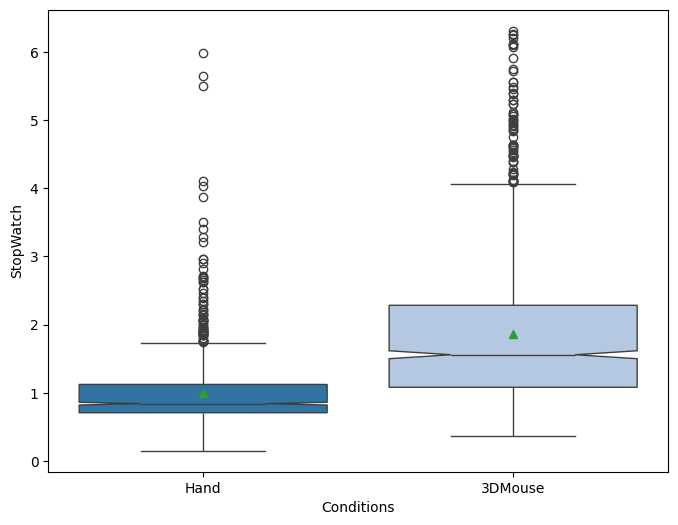

In [53]:
f,ax = plt.subplots(1,1, figsize=(8, 6))
ax = sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Selection')], x = 'Conditions', y = 'StopWatch', showmeans = True, palette = 'tab20', notch = True, order = ['Hand','3DMouse'])

f.savefig('./StopWatchSelectionUX.pdf')


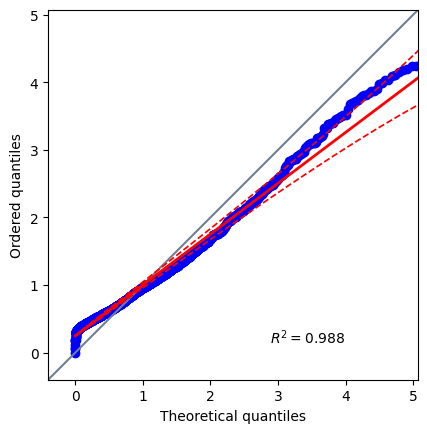

In [54]:
ax = pg.qqplot(allCountdowns[(allCountdowns['UX'] == 'Selection')]['StopWatch'], dist='expon')

In [55]:
pg.sphericity(data = allCountdowns[allCountdowns['UX'] == 'Selection'], 
            dv = 'StopWatch', within = ['Conditions'], subject = 'User')

(True, nan, nan, 1, 1.0)

In [56]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'Selection'], 
            dv = 'StopWatch', within = ['Conditions', 'SizeSelection'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')



/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,21.779115,1,17,21.779115,44.549596,3.913472e-06,3.913472e-06,0.466494,1.000000
1,SizeSelection,3.351748,2,34,1.675874,39.235375,1.470512e-09,2.501924e-08,0.071792,0.835827
2,Conditions * SizeSelection,0.327411,2,34,0.163705,3.748536,3.379441e-02,3.765900e-02,0.007013,0.925408


In [57]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'PathTracing'], 
            dv = 'StopWatch', within = ['Conditions'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


,Source,SS,DF,MS,F,p-unc,n2,eps
0,Conditions,6.117323,1,6.117323,2.259975,0.152237,0.043748,1.0
1,Error,43.308968,16,2.706811,NaN,NaN,NaN,NaN


In [58]:
for i in range(0, len(configSize)):
    for k in range(0, len(conditions)):
        print(configSize[i], conditions[k])
        print(allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['SizeSelection'] == configSize[i])  & (allCountdowns['Conditions'] == conditions[k])]['StopWatch'].describe())

medium Hand
count    360.000000
mean       0.983695
std        0.481572
min        0.150173
25%        0.702573
50%        0.826683
75%        1.095490
max        4.108246
Name: StopWatch, dtype: float64
medium 3DMouse
count    354.000000
mean       1.852043
std        1.133346
min        0.393547
25%        1.066095
50%        1.484822
75%        2.224914
max        6.310677
Name: StopWatch, dtype: float64
large Hand
count    360.000000
mean       0.861792
std        0.314068
min        0.295792
25%        0.674554
50%        0.773500
75%        0.972256
max        4.038002
Name: StopWatch, dtype: float64
large 3DMouse
count    356.000000
mean       1.620510
std        0.839241
min        0.471893
25%        1.031842
50%        1.413986
75%        1.969655
max        5.557053
Name: StopWatch, dtype: float64
small Hand
count    358.000000
mean       1.156649
std        0.659572
min        0.229157
25%        0.767502
50%        0.942673
75%        1.390302
max        5.981224
Name: Sto

In [59]:
for i in range(0, len(configSize)):
    print(configSize[i])
    print(allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['SizeSelection'] == configSize[i]) ]['StopWatch'].describe())

medium
count    714.000000
mean       1.414220
std        0.970288
min        0.150173
25%        0.793979
50%        1.072636
75%        1.652588
max        6.310677
Name: StopWatch, dtype: float64
large
count    716.000000
mean       1.239032
std        0.737114
min        0.295792
25%        0.740824
50%        0.992497
75%        1.456919
max        5.557053
Name: StopWatch, dtype: float64
small
count    697.000000
mean       1.633160
std        1.109083
min        0.229157
25%        0.852348
50%        1.296000
75%        1.962576
max        6.115570
Name: StopWatch, dtype: float64


In [60]:
print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns[(allCountdowns['UX'] == 'Selection')]['StopWatch'], groups = allCountdowns[(allCountdowns['UX'] == 'Selection')]['SizeSelection'], alpha=0.05))



Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
 large medium   0.1752 0.0014 0.0574  0.293   True
 large  small   0.3941    0.0 0.2756 0.5127   True
medium  small   0.2189    0.0 0.1003 0.3375   True
--------------------------------------------------


In [61]:
for i in range(0, len(configSize)):
    print('Config', configSize[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['SizeSelection'] == configSize[i])]['StopWatch'], groups = allCountdowns[(allCountdowns['UX'] == 'Selection') & (allCountdowns['SizeSelection'] == configSize[i])]['Conditions'], alpha=0.05))
    

Config medium
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
3DMouse   Hand  -0.8683   0.0 -0.9959 -0.7408   True
----------------------------------------------------
Config large
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
3DMouse   Hand  -0.7587   0.0 -0.8515 -0.6659   True
----------------------------------------------------
Config small
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
3DMouse   Hand  -0.9797   0.0 -1.1279 -0.8316   True
----------------------------------------------------


In [62]:
post_hocs = pg.pairwise_tests(dv='StopWatch', within='SizeSelection', subject='User', data=allCountdowns[(allCountdowns['UX'] == 'Selection')])
print(post_hocs)

        Contrast       A       B  Paired  Parametric         T   dof  \
0  SizeSelection   large  medium    True        True -5.174610  17.0   
1  SizeSelection   large   small    True        True -8.303255  17.0   
2  SizeSelection  medium   small    True        True -4.211816  17.0   

  alternative         p-unc       BF10    hedges  
0   two-sided  7.616846e-05    358.998 -0.558205  
1   two-sided  2.191249e-07  7.143e+04 -1.266927  
2   two-sided  5.864777e-04     59.449 -0.661839  


In [63]:
post_hocs = pg.pairwise_tests(dv='StopWatch', within='Conditions', subject='User', data=allCountdowns[(allCountdowns['UX'] == 'Selection')])
print(post_hocs)

     Contrast        A     B  Paired  Parametric         T   dof alternative  \
0  Conditions  3DMouse  Hand    True        True  6.757397  17.0   two-sided   

      p-unc      BF10    hedges  
0  0.000003  5942.034  2.088245  


In [64]:
print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns[(allCountdowns['UX'] == 'Selection')]['StopWatch'], groups = allCountdowns[(allCountdowns['UX'] == 'Selection')]['Conditions'], alpha=0.05))
    

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
3DMouse   Hand  -0.8649   0.0 -0.9381 -0.7918   True
----------------------------------------------------


In [65]:
for i in range(0, len(conditions)):
    print(conditions[i])
    print(allCountdowns[(allCountdowns['UX'] == 'Docking') & (allCountdowns['Conditions'] == conditions[i])]['StopWatch'].describe())

Hand
count    310.000000
mean       3.909935
std        1.306111
min        1.274925
25%        2.980526
50%        3.715499
75%        4.536476
max       10.984910
Name: StopWatch, dtype: float64
3DMouse
count    361.000000
mean       4.642161
std        1.870393
min        1.613237
25%        3.355394
50%        4.246460
75%        5.612572
max       11.183640
Name: StopWatch, dtype: float64


In [69]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'Docking'], 
            dv = 'StopWatch', within = ['Conditions', 'BlockID'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,19.712054,1,16,19.712054,14.199518,0.001682,0.001682,0.080798,1.000000
1,BlockID,1.060294,2,32,0.530147,1.769106,0.186754,0.188208,0.004346,0.964724
2,Conditions * BlockID,1.756460,2,32,0.878230,2.400972,0.106775,0.126533,0.007200,0.706378


In [67]:
for i in range(0, len(configDirection)):
    print('Config', configDirection[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns[(allCountdowns['UX'] == 'Docking') & (allCountdowns['DirectionDocking'] == configDirection[i])]['StopWatch'], groups = allCountdowns[(allCountdowns['UX'] == 'Docking') & (allCountdowns['DirectionDocking'] == configDirection[i])]['Conditions'], alpha=0.05))
    

Config X
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand  -0.3637 0.2485 -0.9855 0.2581  False
----------------------------------------------------
Config Y
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand  -0.7701 0.0309 -1.4676 -0.0725   True
-----------------------------------------------------
Config Z
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj  lower  upper  reject
---------------------------------------------------
3DMouse   Hand   -0.634 0.0692 -1.319 0.0509  False
---------------------------------------------------
Config XY
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse  

<Axes: xlabel='Conditions', ylabel='StopWatch'>

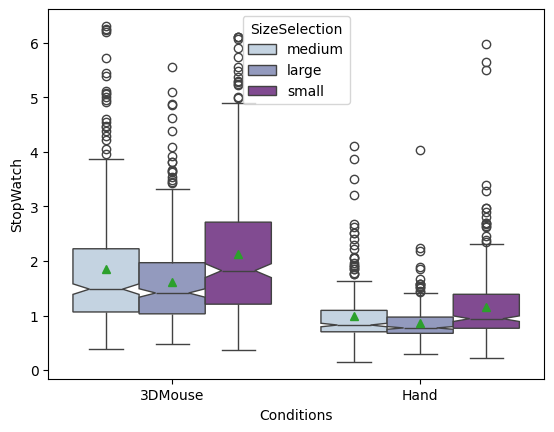

In [68]:
sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Selection')],
            x = 'Conditions',
            y = 'StopWatch', 
            hue = allCountdowns['SizeSelection'],
            showmeans = True, palette = 'BuPu', notch = True)

<Axes: xlabel='Conditions', ylabel='StopWatch'>

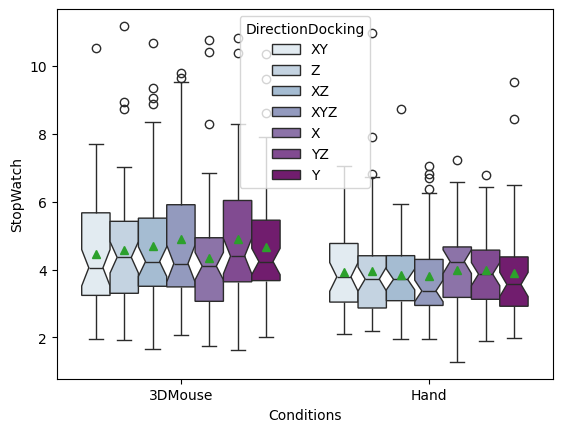

In [21]:
sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Docking')],
            x = 'Conditions',
            y = 'StopWatch', 
            hue = allCountdowns['DirectionDocking'],
            showmeans = True, palette = 'BuPu', notch = True)

<Axes: xlabel='Conditions', ylabel='StopWatch'>

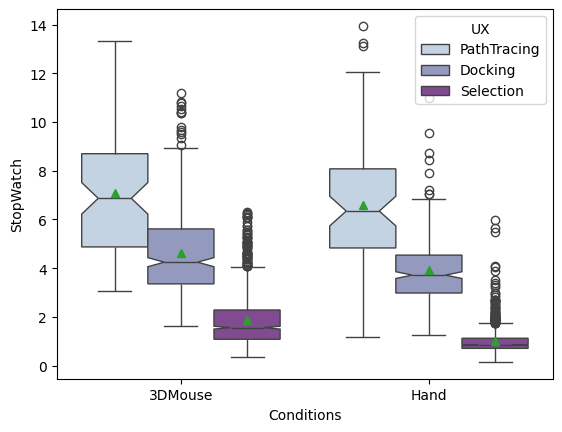

In [22]:
sns.boxplot(data = allCountdowns, x = 'Conditions', y = 'StopWatch', hue = 'UX', showmeans = True, palette = 'BuPu', notch = True)

In [23]:
#print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns['StopWatch'], groups = allCountdowns['UX'], alpha=0.05))


## Significative for countdown for hand better than mouse

In [24]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'Docking'], 
            dv = 'StopWatch', within = ['Conditions', 'DirectionDocking'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,45.868142,1,16,45.868142,14.227023,0.001669,0.001669,0.075396,1.000000
1,DirectionDocking,2.847229,6,96,0.474538,0.979417,0.443528,0.427918,0.004680,0.706327
2,Conditions * DirectionDocking,5.241020,6,96,0.873503,1.884340,0.091280,0.129647,0.008615,0.618702


In [25]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'PathTracing'], 
            dv = 'StopWatch', within = ['Conditions'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


,Source,SS,DF,MS,F,p-unc,n2,eps
0,Conditions,6.117323,1,6.117323,2.259975,0.152237,0.043748,1.0
1,Error,43.308968,16,2.706811,NaN,NaN,NaN,NaN


In [26]:
writeOutlierDocking

,index,BlockID,Config,StopWatch,AccDistance,User,Conditions,UX,SizeSelection,DirectionDocking,CircuitID
0,0.0,0,2,11.36046,1.645455,User15,3DMouse,Docking,NaN,Z,NaN
1,2.0,0,6,15.37588,1.038536,User15,3DMouse,Docking,NaN,XYZ,NaN
2,4.0,0,1,11.35157,1.260522,User15,3DMouse,Docking,NaN,Y,NaN
3,5.0,0,4,14.39375,1.158365,User15,3DMouse,Docking,NaN,XZ,NaN
4,9.0,1,2,13.67823,1.036293,User15,3DMouse,Docking,NaN,Z,NaN
5,10.0,1,5,13.01598,0.814516,User15,3DMouse,Docking,NaN,YZ,NaN
6,12.0,1,3,12.97824,0.764332,User15,3DMouse,Docking,NaN,XY,NaN
7,13.0,1,6,12.78011,1.1755,User15,3DMouse,Docking,NaN,XYZ,NaN
8,18.0,2,5,13.76732,0.994376,User15,3DMouse,Docking,NaN,YZ,NaN
9,19.0,2,4,18.72588,1.751788,User15,3DMouse,Docking,NaN,XZ,NaN


In [71]:
allDistances = pd.DataFrame()

for i in range(0, len(nameList)):
    for k in range(0, len(conditions)):
        resultsDistances = None

        resultsDistances = pd.read_csv('./UserData/' + nameList[i] + '/' + conditions[k] + '-Docking-Position.csv', sep = ';', decimal = '.')
        resultsDistances['User'] = nameList[i]
        resultsDistances['Conditions'] = conditions[k]
        resultsDistances['UX'] = 'Docking'
        allDistances = pd.concat([resultsDistances, allDistances], axis = 0)

for i in range(0, len(configDirection)):
    allDistances.loc[(allCountdowns['Config'] == i), 'DirectionDocking'] = configDirection[i]

del allDistances['RotationTarget'], allDistances['RotationFinal']

allDistances = allDistances.reset_index()
allDistances['DistanceFinal'].apply(lambda x: float(x))
allDistances['DistanceFinal'] = allDistances['DistanceFinal']*2

allDistances['PositionTargetX'].apply(lambda x: float(x))
allDistances['PositionTargetY'].apply(lambda x: float(x))
allDistances['PositionTargetZ'].apply(lambda x: float(x))
allDistances['PositionFinalX'].apply(lambda x: float(x))
allDistances['PositionFinalY'].apply(lambda x: float(x))
allDistances['PositionFinalZ'].apply(lambda x: float(x))

#NEED TO MULYIPLY BY TWO TO CONVERT INTO CM FROM UNITY (10 == 20cm in real life)
#allDistances['DistanceVerif'] = (allDistances['PositionTargetX'] - allDistances['PositionFinalX'])**2 + (allDistances['PositionTargetY'] - allDistances['PositionFinalY'])**2 + (allDistances['PositionTargetZ'] - allDistances['PositionFinalZ'])**2
#allDistances['VerifDistance'] = (allDistances['DistanceVerif']).apply(np.sqrt)

allDistances.loc[allDistances['DirectionDocking'] == 'X', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetX'] - allDistances['PositionFinalX'])**2).apply(np.sqrt)
allDistances.loc[allDistances['DirectionDocking'] == 'Y', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetY'] - allDistances['PositionFinalY'])**2).apply(np.sqrt)
allDistances.loc[allDistances['DirectionDocking'] == 'Z', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetZ'] - allDistances['PositionFinalZ'])**2).apply(np.sqrt)

allDistances.loc[allDistances['DirectionDocking'] == 'XY', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetX'] - allDistances['PositionFinalX'])**2 + (allDistances['PositionTargetY'] - allDistances['PositionFinalY'])**2).apply(np.sqrt)
allDistances.loc[allDistances['DirectionDocking'] == 'XZ', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetX'] - allDistances['PositionFinalX'])**2 + (allDistances['PositionTargetZ'] - allDistances['PositionFinalZ'])**2).apply(np.sqrt)
allDistances.loc[allDistances['DirectionDocking'] == 'YZ', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetY'] - allDistances['PositionFinalY'])**2 + (allDistances['PositionTargetZ'] - allDistances['PositionFinalZ'])**2).apply(np.sqrt)

allDistances.loc[allDistances['DirectionDocking'] == 'XYZ', 'AccuracyInDirection'] = 2*((allDistances['PositionTargetX'] - allDistances['PositionFinalX'])**2 + (allDistances['PositionTargetY'] - allDistances['PositionFinalY'])**2 + (allDistances['PositionTargetZ'] - allDistances['PositionFinalZ'])**2).apply(np.sqrt)

for i in range(0, len(writeOutlierDocking)):
    allDistances = allDistances.drop(allDistances[(allDistances['User'] == writeOutlierDocking['User'].iloc[i]) & (allDistances['Config'] == writeOutlierDocking['Config'].iloc[i]) & (allDistances['Conditions'] == writeOutlierDocking['Conditions'].iloc[i]) & (allDistances['BlockID'] == writeOutlierDocking['BlockID'].iloc[i])].index)


/var/folders/xd/qgqqknts7d16j8g06t07y4yw0000gn/T/ipykernel_37437/405395147.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  allDistances = pd.concat([resultsDistances, allDistances], axis = 0)


In [72]:
outlierCount = 0
removedLine = []

stats.zscore(allDistances['AccuracyInDirection'])
testOutliers = allDistances
for j in range(0, len(testOutliers['AccuracyInDirection'])):
    if(np.abs(stats.zscore(testOutliers['AccuracyInDirection']).iloc[j] > 3)):
        #print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j])
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allDistances = allDistances.drop(index = removedLine[i])

outlierCount

21

In [73]:
outlierCount = 0
removedLine = []

stats.zscore(allDistances['DistanceFinal'])
testOutliers = allDistances
for j in range(0, len(testOutliers['DistanceFinal'])):
    if(np.abs(stats.zscore(testOutliers['DistanceFinal']).iloc[j] > 3)):
        #print('Line', j, testOutliers['User'].iloc[j], 'Index', testOutliers.index[j])
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    allDistances = allDistances.drop(index = removedLine[i])

outlierCount

10

/var/folders/xd/qgqqknts7d16j8g06t07y4yw0000gn/T/ipykernel_37437/533184223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data = allDistances[(allDistances['UX'] == 'Docking')],


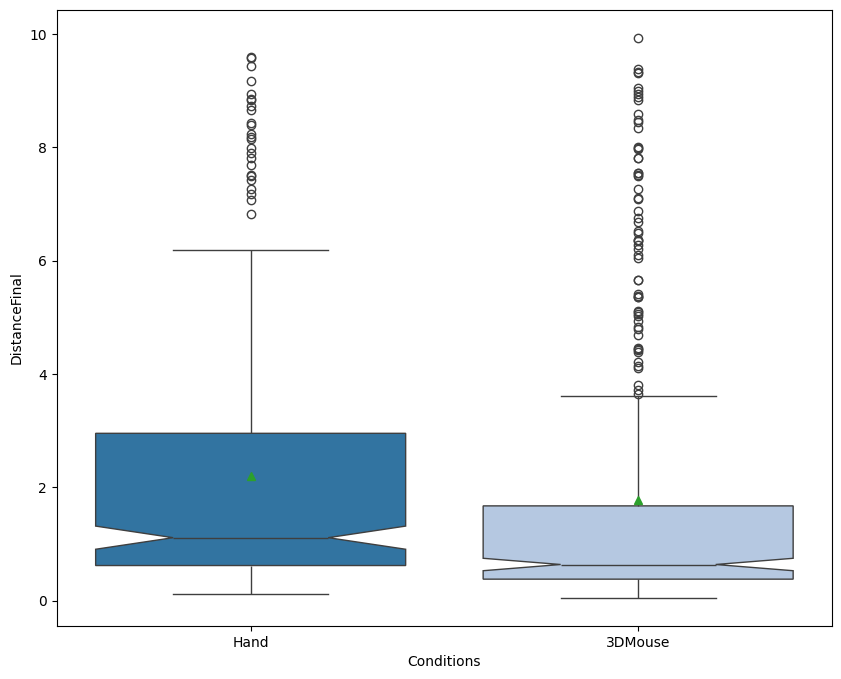

In [74]:
f,ax = plt.subplots(1,1, figsize=(10, 8))

ax = sns.boxplot(data = allDistances[(allDistances['UX'] == 'Docking')],
            x = 'Conditions',
            y = 'DistanceFinal',
            showmeans = True, palette = 'tab20', notch = True, order = ['Hand','3DMouse'])

f.savefig('./Accuracy-cm.pdf')


In [75]:
pg.rm_anova(data = allDistances[allDistances['UX'] == 'Docking'], 
            dv = 'DistanceFinal', within = ['Conditions', 'DirectionDocking'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,13.453939,1,15,13.453939,10.342403,0.005772,0.005772,0.019198,1.000000
1,DirectionDocking,11.366742,6,90,1.894457,0.774487,0.592004,0.525017,0.016220,0.550812
2,Conditions * DirectionDocking,5.690452,6,90,0.948409,0.408039,0.871955,0.818849,0.008120,0.731106


In [614]:
post_hocs = pg.pairwise_tests(dv='DistanceFinal', within=['Conditions'], subject='User', data= allDistances[allDistances['UX'] == 'Docking'])
print(post_hocs)

     Contrast        A     B  Paired  Parametric         T   dof alternative  \
0  Conditions  3DMouse  Hand    True        True -3.457265  16.0   two-sided   

      p-unc    BF10   hedges  
0  0.003243  13.811 -0.40416  


In [76]:
pg.rm_anova(data = allDistances[allDistances['UX'] == 'Docking'], 
            dv = 'DistanceFinal', within = ['Conditions', 'BlockID'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,4.765227,1,16,4.765227,13.978521,0.001790,0.001790,0.031105,1.000000
1,BlockID,0.460858,2,32,0.230429,0.282952,0.755422,0.743912,0.003008,0.947727
2,Conditions * BlockID,0.062842,2,32,0.031421,0.043826,0.957178,0.944488,0.000410,0.899108


In [619]:
post_hocs = pg.pairwise_tests(dv='DistanceFinal', within=['DirectionDocking'], subject='User', data= allDistances[allDistances['UX'] == 'Docking'])
print(post_hocs)

            Contrast    A    B  Paired  Parametric         T   dof  \
0   DirectionDocking    X   XY    True        True  0.271551  17.0   
1   DirectionDocking    X  XYZ    True        True  0.233192  17.0   
2   DirectionDocking    X   XZ    True        True  0.949832  17.0   
3   DirectionDocking    X    Y    True        True  0.027646  17.0   
4   DirectionDocking    X   YZ    True        True -1.009186  17.0   
5   DirectionDocking    X    Z    True        True  1.819106  17.0   
6   DirectionDocking   XY  XYZ    True        True -0.094163  17.0   
7   DirectionDocking   XY   XZ    True        True  0.371897  17.0   
8   DirectionDocking   XY    Y    True        True -0.281717  17.0   
9   DirectionDocking   XY   YZ    True        True -1.190595  17.0   
10  DirectionDocking   XY    Z    True        True  1.401694  17.0   
11  DirectionDocking  XYZ   XZ    True        True  0.560078  17.0   
12  DirectionDocking  XYZ    Y    True        True -0.245511  17.0   
13  DirectionDocking

In [618]:
post_hocs = pg.pairwise_tests(dv='StopWatch', within=['DirectionDocking', 'Conditions'], subject='User', data= allCountdowns[allCountdowns['UX'] == 'Docking'])
print(post_hocs[post_hocs['p-unc'] < 0.06])

                         Contrast DirectionDocking        A     B Paired  \
21                     Conditions                -  3DMouse  Hand   True   
23  DirectionDocking * Conditions               XY  3DMouse  Hand   True   
24  DirectionDocking * Conditions              XYZ  3DMouse  Hand   True   
25  DirectionDocking * Conditions               XZ  3DMouse  Hand   True   
26  DirectionDocking * Conditions                Y  3DMouse  Hand   True   
27  DirectionDocking * Conditions               YZ  3DMouse  Hand   True   
28  DirectionDocking * Conditions                Z  3DMouse  Hand   True   

   Parametric         T   dof alternative     p-unc    BF10    hedges  
21       True  3.771873  16.0   two-sided  0.001669  24.339  0.596024  
23       True  2.379520  16.0   two-sided  0.030121   2.193  0.437244  
24       True  4.075434  16.0   two-sided  0.000881  42.205  0.781626  
25       True  3.183937  16.0   two-sided  0.005769   8.498  0.703460  
26       True  2.904201  16.0  

In [616]:
post_hocs = pg.pairwise_tests(dv='DistanceFinal', within=['Conditions', 'DirectionDocking'], subject='User', data= allDistances[allDistances['UX'] == 'Docking'])
print(post_hocs[post_hocs['p-unc'] < 0.06])

     Contrast Conditions        A     B Paired Parametric         T   dof  \
0  Conditions          -  3DMouse  Hand   True       True -3.215961  15.0   

  alternative     p-unc   BF10    hedges  
0   two-sided  0.005772  8.632 -0.446054  


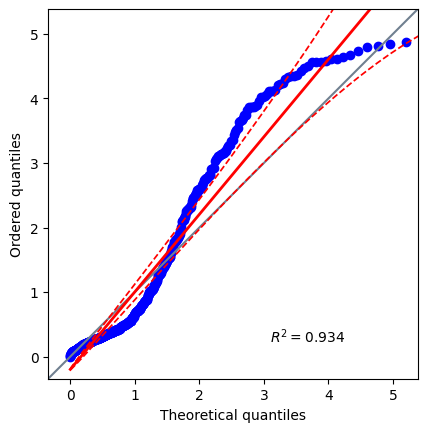

In [262]:
ax = pg.qqplot(allDistances['DistanceFinal'], dist='expon')
#ax = pg.qqplot(allDistances['AccuracyInDirection'], dist='expon')

In [33]:
allDistances[allDistances['Conditions'] == 'Hand']['DistanceFinal'].describe(), allDistances[allDistances['Conditions'] == '3DMouse']['DistanceFinal'].describe()

(count    321.000000
 mean       2.198512
 std        2.310187
 min        0.112600
 25%        0.618400
 50%        1.110200
 75%        2.952600
 max        9.595800
 Name: DistanceFinal, dtype: float64,
 count    343.000000
 mean       1.771725
 std        2.413493
 min        0.050200
 25%        0.378000
 50%        0.636600
 75%        1.671600
 max        9.936200
 Name: DistanceFinal, dtype: float64)

In [263]:
#allDistances[allDistances['Conditions'] == 'Hand']['AccuracyInDirection'].describe(), allDistances[allDistances['Conditions'] == '3DMouse']['AccuracyInDirection'].describe()

In [37]:
#allDistances['DirectionDocking']

1        Y
2        Z
3       XY
4       XZ
5       XY
      ... 
730     XZ
731     YZ
732     XY
733      Z
734    XYZ
Name: DirectionDocking, Length: 664, dtype: object

In [264]:
#pg.rm_anova(data = allDistances[allDistances['UX'] == 'Docking'], 
#            dv = 'AccuracyInDirection', within = ['Conditions', 'DirectionDocking'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


In [265]:
#print(sm.stats.multicomp.pairwise_tukeyhsd(allDistances['AccuracyInDirection'], groups = allDistances['Conditions'], alpha=0.05))


In [40]:
print(sm.stats.multicomp.pairwise_tukeyhsd(allDistances['DistanceFinal'], groups = allDistances['Conditions'], alpha=0.05))


Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj  lower  upper  reject
---------------------------------------------------
3DMouse   Hand   0.4268 0.0204 0.0663 0.7873   True
---------------------------------------------------


In [266]:
#print(sm.stats.multicomp.pairwise_tukeyhsd(allDistances['AccuracyInDirection'], groups = allDistances['DirectionDocking'], alpha=0.05))


In [276]:
for i in range(0, len(configDirection)):
    for k in range(0, len(conditions)):
        print(configDirection[i], conditions[k])
        print(allDistances[(allDistances['DirectionDocking'] == configDirection[i]) & (allDistances['Conditions'] == conditions[k])]['DistanceFinal'].describe())
    

X Hand
count    42.000000
mean      2.215719
std       2.233886
min       0.172800
25%       0.766150
50%       1.163100
75%       2.942800
max       7.897800
Name: DistanceFinal, dtype: float64
X 3DMouse
count    46.000000
mean      1.876974
std       2.282867
min       0.164000
25%       0.463100
50%       0.680600
75%       2.655050
max       7.542400
Name: DistanceFinal, dtype: float64
Y Hand
count    46.000000
mean      2.242370
std       2.427771
min       0.158600
25%       0.585700
50%       1.063800
75%       3.083600
max       8.856600
Name: DistanceFinal, dtype: float64
Y 3DMouse
count    51.000000
mean      2.100412
std       2.953235
min       0.141200
25%       0.370200
50%       0.628000
75%       2.266800
max       9.936200
Name: DistanceFinal, dtype: float64
Z Hand
count    62.00000
mean      1.92370
std       2.06321
min       0.13220
25%       0.62510
50%       0.99580
75%       2.04435
max       8.93580
Name: DistanceFinal, dtype: float64
Z 3DMouse
count    65.00000

In [277]:
print(sm.stats.multicomp.pairwise_tukeyhsd(allDistances['DistanceFinal'], groups = allDistances['DirectionDocking'], alpha=0.05))


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     X     XY  -0.0092    1.0 -1.0423 1.0239  False
     X    XYZ  -0.0054    1.0 -1.0385 1.0277  False
     X     XZ  -0.1802 0.9986 -1.2134 0.8529  False
     X      Y   0.1291 0.9998  -0.904 1.1622  False
     X     YZ   0.3195 0.9841 -0.8497 1.4887  False
     X      Z    -0.42 0.8627 -1.3934 0.5533  False
    XY    XYZ   0.0038    1.0 -1.0039 1.0115  False
    XY     XZ   -0.171 0.9988 -1.1787 0.8366  False
    XY      Y   0.1383 0.9997 -0.8694  1.146  False
    XY     YZ   0.3287 0.9797 -0.8181 1.4754  False
    XY      Z  -0.4108 0.8593 -1.3571 0.5355  False
   XYZ     XZ  -0.1748 0.9987 -1.1825 0.8328  False
   XYZ      Y   0.1345 0.9997 -0.8732 1.1422  False
   XYZ     YZ   0.3249 0.9809 -0.8219 1.4716  False
   XYZ      Z  -0.4146 0.8539 -1.3609 0.5317  False
    XZ      Y   0.3093 0.9713 -0.6984  1.317  False
    XZ     Y

In [43]:
allDistances[(allDistances['DirectionDocking'] == 'Z') & (allDistances['Conditions'] == 'Hand')]['AccuracyInDirection'].describe()

count    62.000000
mean      0.891523
std       1.701028
min       0.015600
25%       0.134550
50%       0.352800
75%       0.605650
max       8.350800
Name: AccuracyInDirection, dtype: float64

In [44]:
allDistances[(allDistances['DirectionDocking'] == 'Z') & (allDistances['Conditions'] == '3DMouse')]['AccuracyInDirection'].describe()

count    65.000000
mean      0.491662
std       1.203629
min       0.000000
25%       0.109800
50%       0.186400
75%       0.301400
max       8.706200
Name: AccuracyInDirection, dtype: float64

<Axes: xlabel='Conditions', ylabel='AccDistance'>

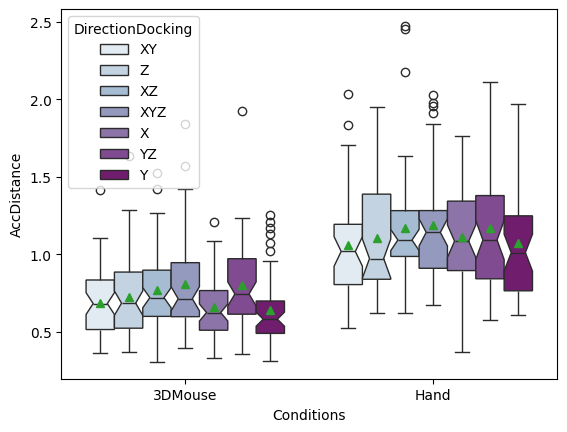

In [45]:
sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Docking')],
            x = 'Conditions',
            y = 'AccDistance', hue = 'DirectionDocking',
            showmeans = True, palette = 'BuPu', notch = True)

/var/folders/xd/qgqqknts7d16j8g06t07y4yw0000gn/T/ipykernel_29878/888361822.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Docking')],


<Axes: xlabel='Conditions', ylabel='AccDistance'>

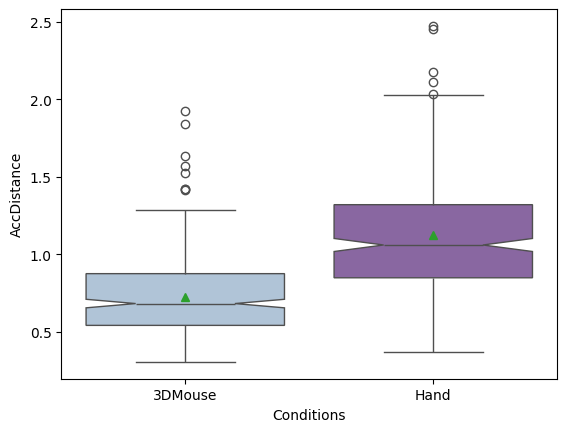

In [46]:
sns.boxplot(data = allCountdowns[(allCountdowns['UX'] == 'Docking')],
            x = 'Conditions',
            y = 'AccDistance',
            showmeans = True, palette = 'BuPu', notch = True)

In [47]:
allCountdowns[allCountdowns['AccDistance'] > 3]

,index,BlockID,Config,StopWatch,AccDistance,User,Conditions,UX,SizeSelection,DirectionDocking,CircuitID
86,0.0,0,0,8.753071,3.112171,User20,Hand,PathTracing,NaN,NaN,0.0
347,3.0,0,3,8.082211,3.240855,User18,3DMouse,PathTracing,NaN,NaN,3.0
1119,1.0,0,1,4.034845,3.051085,User14,Hand,PathTracing,NaN,NaN,1.0
1637,3.0,0,3,7.467770,3.038560,User10,Hand,PathTracing,NaN,NaN,3.0
1960,3.0,0,3,4.819012,3.384289,User8,Hand,PathTracing,NaN,NaN,3.0
2647,2.0,0,2,10.667080,3.300767,User4,Hand,PathTracing,NaN,NaN,2.0
2649,4.0,0,4,9.519867,3.016099,User4,Hand,PathTracing,NaN,NaN,4.0


In [48]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'Docking'], 
            dv = 'AccDistance', within = ['Conditions'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


,Source,SS,DF,MS,F,p-unc,n2,eps
0,Conditions,1.529341,1,1.529341,38.314683,0.000013,0.540698,1.0
1,Error,0.638645,16,0.039915,NaN,NaN,NaN,NaN


In [49]:
print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns[allCountdowns['UX'] == 'Docking']['AccDistance'], groups = allCountdowns[allCountdowns['UX'] == 'Docking']['Conditions'], alpha=0.05))


Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj lower  upper  reject
--------------------------------------------------
3DMouse   Hand   0.3991   0.0 0.3518 0.4464   True
--------------------------------------------------


In [50]:
for i in range(0, len(configDirection)):
    print('Direction', configDirection[i], ' Accumulated distance')
    print(sm.stats.multicomp.pairwise_tukeyhsd(allCountdowns[allCountdowns['DirectionDocking'] == configDirection[i]]['AccDistance'], groups = allCountdowns[allCountdowns['DirectionDocking'] == configDirection[i]]['Conditions'], alpha=0.05))


Direction X  Accumulated distance
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj lower  upper  reject
--------------------------------------------------
3DMouse   Hand   0.4512   0.0 0.3488 0.5536   True
--------------------------------------------------
Direction Y  Accumulated distance
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj lower  upper reject
-------------------------------------------------
3DMouse   Hand   0.4317   0.0 0.3064 0.557   True
-------------------------------------------------
Direction Z  Accumulated distance
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj lower  upper  reject
--------------------------------------------------
3DMouse   Hand   0.3811   0.0 0.2535 0.5087   True
--------------------------------------------------
Direction XY  Accumulated distance
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj lower  upper  rej

## All significative for accumulated distance on condition, with better results for mouse. Accuracy significative on Z with better on mouse  

<Axes: xlabel='Conditions', ylabel='DistanceFinal'>

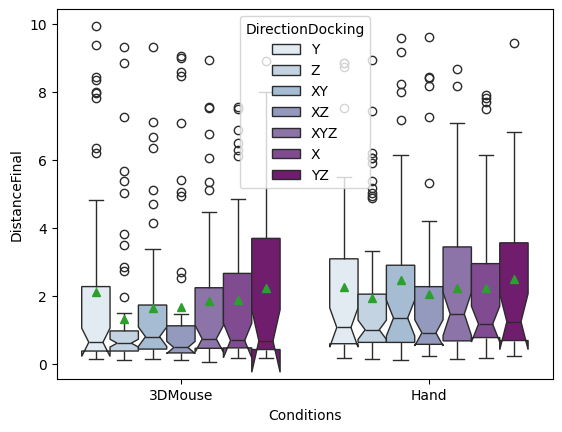

In [51]:
sns.boxplot(data = allDistances[(allDistances['UX'] == 'Docking')],
            x = 'Conditions',
            y = 'DistanceFinal', 
            hue = allDistances['DirectionDocking'],
            showmeans = True, palette = 'BuPu', notch = True)

In [52]:
allDistances

,index,BlockID,TrialID,Config,DistanceFinal,PositionTargetX,PositionTargetY,PositionTargetZ,PositionFinalX,PositionFinalY,PositionFinalZ,User,Conditions,UX,DirectionDocking,AccuracyInDirection
1,1,0,1,2,8.3508,1.4150,0.2762,0.3709,-1.8540,0.9697,2.8741,User20,3DMouse,Docking,Y,1.387000
2,2,0,2,4,0.7378,2.6639,-0.0924,-2.7347,2.9211,0.1424,-2.6131,User20,3DMouse,Docking,Z,0.243200
3,3,0,3,6,0.9046,1.7687,-1.0828,2.0193,2.0930,-0.7677,2.0311,User20,3DMouse,Docking,XY,0.904342
4,4,0,4,0,0.4224,-1.5749,0.7800,-0.8968,-1.6647,0.6052,-0.9739,User20,3DMouse,Docking,XZ,0.236715
5,5,0,5,5,3.3590,-1.7444,0.0433,-0.4295,-0.6660,-1.0529,0.2460,User20,3DMouse,Docking,XY,3.075452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,16,2,16,5,0.7062,-1.9702,-0.5593,2.3503,-2.1116,-0.8800,2.3925,User1,Hand,Docking,XZ,0.295126
731,17,2,17,0,0.5112,0.3843,-0.4694,-3.0557,0.6050,-0.5364,-3.1659,User1,Hand,Docking,YZ,0.257938
732,18,2,18,6,1.5190,0.6568,-1.1509,0.6120,1.0282,-0.4904,0.5606,User1,Hand,Docking,XY,1.515517
733,19,2,19,3,1.0064,-2.6672,1.0330,3.4724,-2.7247,0.5499,3.3441,User1,Hand,Docking,Z,0.256600


<Axes: xlabel='Conditions', ylabel='AccuracyInDirection'>

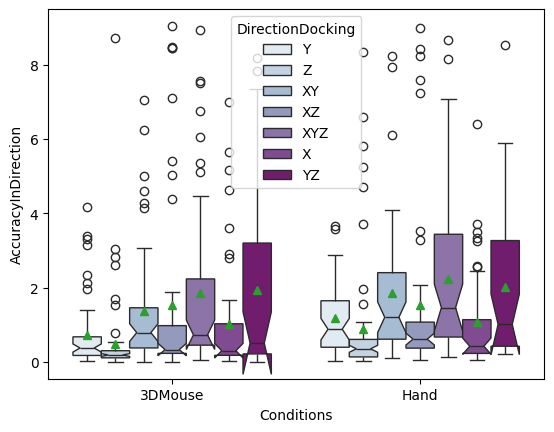

In [53]:
sns.boxplot(data = allDistances[(allDistances['UX'] == 'Docking')],
            x = 'Conditions',
            y = 'AccuracyInDirection', 
            hue = allDistances['DirectionDocking'],
            showmeans = True, palette = 'BuPu', notch = True)

In [16]:
headers = ['BlockID', 'Frame', 'StopWatch', 'PosX', 'PosY', 'PosZ']

In [17]:
writeOutlierPathTracing

,index,BlockID,Config,StopWatch,AccDistance,User,Conditions,UX,SizeSelection,DirectionDocking,CircuitID
0,2.0,0,2,18.97876,2.301507,User11,3DMouse,PathTracing,NaN,NaN,2.0
1,4.0,0,4,18.313,2.336265,User11,3DMouse,PathTracing,NaN,NaN,4.0
2,4.0,0,4,7.025513,3.900026,User10,Hand,PathTracing,NaN,NaN,4.0


In [18]:
allCircuits = pd.DataFrame()

for i in range(0, len(nameList)):
    for k in range(0, len(conditions)):
        resultsCircuits = None
        
        for j in range(0, len(measureCircuit)):
            resultsCircuits = pd.read_csv('./UserData/' + nameList[i] + '/' + conditions[k] + '-PathTracing-' + measureCircuit[j] + '.csv', sep = ';', decimal = '.', names = headers, skiprows = [0,2])
            resultsCircuits['User'] = nameList[i]
            resultsCircuits['Conditions'] = conditions[k]
            resultsCircuits['CircuitID'] = measureCircuit[j]
            resultsCircuits['UX'] = 'PathTracing'
            allCircuits = pd.concat([resultsCircuits, allCircuits], axis = 0)

allCircuits['StopWatch'].apply(lambda x: float(x))
allCircuits = allCircuits[allCircuits['PosX'] < 4]
allCircuits = allCircuits[allCircuits['PosY'] < 2]
allCircuits = allCircuits[allCircuits['PosZ'] < 4]
allCircuits = allCircuits[allCircuits['PosX'] > -4]
allCircuits = allCircuits[allCircuits['PosY'] > -2]
allCircuits = allCircuits[allCircuits['PosZ'] > -4]

for i in range(0, len(writeOutlierPathTracing)):
    allCircuits = allCircuits.drop(allCircuits[(allCircuits['User'] == writeOutlierPathTracing['User'].iloc[i]) & (allCircuits['CircuitID'] == writeOutlierPathTracing['CircuitID'].iloc[i]) & (allCircuits['Conditions'] == writeOutlierPathTracing['Conditions'].iloc[i])].index)


for i in range(0, len(measureCircuit)):
    for k in range(0, len(conditions)):
        cond = (allCircuits['CircuitID'] == measureCircuit[i]) & (allCircuits['Conditions'] == conditions[k])
        allCircuits[cond].reset_index().to_csv('./AllCircuits_'+str(i)+'-' + conditions[k] +'.csv', sep = ';', decimal = ',')

In [19]:
allCircuits.head()

,BlockID,Frame,StopWatch,PosX,PosY,PosZ,User,Conditions,CircuitID,UX
0,0,1,0.049927,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing
1,0,3,0.084286,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing
2,0,4,0.101349,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing
3,0,5,0.120125,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing
4,0,6,0.139626,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing


In [58]:
allCircuits['PositionAbsolute'] = (allCircuits['PosX']**2 + allCircuits['PosY']**2 + allCircuits['PosZ']**2).apply(np.sqrt)


In [59]:

realAccDistancePT = pd.DataFrame()

In [60]:
allCircuits = allCircuits.dropna()
line = 0
for i in range(0, len(nameList)):
    for j in range(0, 5):
        newDf = pd.DataFrame()
        cond = (allCircuits['CircuitID'] == measureCircuit[j]) & (allCircuits['User'] == nameList[i])  & (allCircuits['Conditions'] == conditions[0])
        allCircuits['PositionSubstraction'] = abs(allCircuits[cond]['PositionAbsolute'].diff().fillna(0))*2
        newDf=abs(allCircuits[cond]['PositionAbsolute'].diff().fillna(0))*2
        realAccDistancePT.loc[line, 'User'] = nameList[i]
        realAccDistancePT.loc[line, 'Conditions'] = conditions[0]
        realAccDistancePT.loc[line, 'CircuitID'] = measureCircuit[j]
        realAccDistancePT.loc[line, 'AccDistance'] = newDf.sum()
        line = line + 1

for i in range(0, len(nameList)):
    for j in range(0, 5):
        newDf = pd.DataFrame()
        cond = (allCircuits['CircuitID'] == measureCircuit[j]) & (allCircuits['User'] == nameList[i])  & (allCircuits['Conditions'] == conditions[1])
        allCircuits['PositionSubstraction'] = abs(allCircuits[cond]['PositionAbsolute'].diff().fillna(0))*2
        newDf=abs(allCircuits[cond]['PositionAbsolute'].diff().fillna(0))*2
        realAccDistancePT.loc[line, 'User'] = nameList[i]
        realAccDistancePT.loc[line, 'Conditions'] = conditions[1]
        realAccDistancePT.loc[line, 'CircuitID'] = measureCircuit[j]
        realAccDistancePT.loc[line, 'AccDistance'] = newDf.sum()
        line = line + 1

#multiply by 2 because of the scale of the diffuser
allCircuits = allCircuits.dropna()



In [61]:
realAccDistancePT[realAccDistancePT['User'] == 'User19']

,User,Conditions,CircuitID,AccDistance
80,User19,Hand,Circuit0,13.426115
81,User19,Hand,Circuit1,12.492389
82,User19,Hand,Circuit2,12.876724
83,User19,Hand,Circuit3,12.198558
84,User19,Hand,Circuit4,16.344852
170,User19,3DMouse,Circuit0,19.664080
171,User19,3DMouse,Circuit1,25.488701
172,User19,3DMouse,Circuit2,21.810529
173,User19,3DMouse,Circuit3,22.665452
174,User19,3DMouse,Circuit4,15.884945


In [62]:
allCircuits['PositionSubstraction'].describe()


count    62964.000000
mean         0.047860
std          0.047363
min          0.000000
25%          0.009028
50%          0.035444
75%          0.069858
max          0.178062
Name: PositionSubstraction, dtype: float64

In [63]:
newDf.sum()

np.float64(20.11634956201867)

In [64]:
outlierCount = 0
removedLine = []

stats.zscore(realAccDistancePT['AccDistance'])
testOutliers = realAccDistancePT
for j in range(0, len(testOutliers['AccDistance'])):
    if(np.abs(stats.zscore(testOutliers['AccDistance']).iloc[j] > 3)):
        print('Line', j, testOutliers['User'].iloc[j])
        outlierCount = outlierCount + 1
        removedLine.append(testOutliers.index[j])

for i in range(0, outlierCount):
    #print(removedLine[i])
    realAccDistancePT = realAccDistancePT.drop(index = removedLine[i])

outlierCount

Line 40 User10
Line 41 User10
Line 67 User16
Line 69 User16


4

In [65]:
allCircuits[(allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['User'] == nameList[0])  & (allCircuits['Conditions'] == conditions[0])][-20:]

,BlockID,Frame,StopWatch,PosX,PosY,PosZ,User,Conditions,CircuitID,UX,PositionAbsolute,PositionSubstraction
405,0,406,10.74920,2.4812,0.7547,0.0934,User1,Hand,Circuit0,PathTracing,2.595120,0.003071
406,0,407,10.77478,2.4812,0.7547,0.0934,User1,Hand,Circuit0,PathTracing,2.595120,0.000000
407,0,408,10.79908,2.4812,0.7547,0.0934,User1,Hand,Circuit0,PathTracing,2.595120,0.000000
408,0,409,10.82836,2.5338,0.6686,-0.1133,User1,Hand,Circuit0,PathTracing,2.622976,0.000000
409,0,410,10.85171,2.5338,0.6686,-0.1133,User1,Hand,Circuit0,PathTracing,2.622976,0.000000
410,0,411,10.87981,2.5247,0.5714,-0.1373,User1,Hand,Circuit0,PathTracing,2.592192,0.000000
411,0,412,10.90460,2.5247,0.5714,-0.1373,User1,Hand,Circuit0,PathTracing,2.592192,0.000000
412,0,413,10.93497,2.5062,0.5820,-0.3214,User1,Hand,Circuit0,PathTracing,2.592886,0.000000
413,0,414,10.96332,2.5221,0.6887,-0.6026,User1,Hand,Circuit0,PathTracing,2.682988,0.000000
414,0,415,10.98731,2.5221,0.6887,-0.6026,User1,Hand,Circuit0,PathTracing,2.682988,0.000000


In [66]:
#realAccDistancePT = pd.DataFrame()
#line = 0
#for i in range(0, len(nameList)):
#    for j in range(0, 5):
#        for k in range(0, len(conditions)):
#            cond = (allCircuits['CircuitID'] == measureCircuit[j]) & (allCircuits['User'] == nameList[i])  & (allCircuits['Conditions'] == conditions[k])
#            realAccDistancePT.loc[line, 'User'] = nameList[i]
#            realAccDistancePT.loc[line, 'Conditions'] = conditions[k]
#            realAccDistancePT.loc[line, 'CircuitID'] = measureCircuit[j]
#            realAccDistancePT.loc[line, 'AccDistance'] = allCircuits[cond]['PositionSubstraction'].sum()
#            line = line + 1


In [67]:
realAccDistancePT[realAccDistancePT['User'] == 'User1']

,User,Conditions,CircuitID,AccDistance
0,User1,Hand,Circuit0,20.881858
1,User1,Hand,Circuit1,19.845946
2,User1,Hand,Circuit2,15.637595
3,User1,Hand,Circuit3,16.728986
4,User1,Hand,Circuit4,24.455405
90,User1,3DMouse,Circuit0,11.387570
91,User1,3DMouse,Circuit1,12.364009
92,User1,3DMouse,Circuit2,16.356681
93,User1,3DMouse,Circuit3,9.367055
94,User1,3DMouse,Circuit4,16.094640


<Axes: xlabel='Conditions', ylabel='AccDistance'>

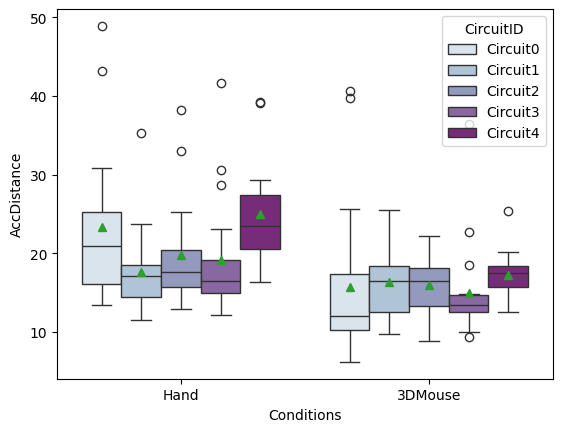

In [68]:
sns.boxplot(data = realAccDistancePT,
            x = 'Conditions',
            y = 'AccDistance', hue = 'CircuitID',
            showmeans = True, palette = 'BuPu')

In [69]:
realAccDistancePT[realAccDistancePT['Conditions'] == 'Hand']['AccDistance'].describe(), realAccDistancePT[realAccDistancePT['Conditions'] == '3DMouse']['AccDistance'].describe()

(count    86.000000
 mean     20.948752
 std       7.674420
 min      11.454668
 25%      15.693105
 50%      18.442824
 75%      23.670958
 max      48.898314
 Name: AccDistance, dtype: float64,
 count    90.000000
 mean     16.048850
 std       5.954894
 min       6.168919
 25%      12.467365
 50%      15.053740
 75%      18.134130
 max      40.672977
 Name: AccDistance, dtype: float64)

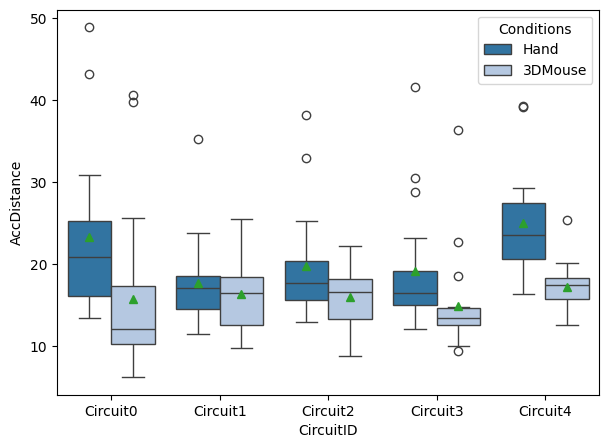

In [70]:
f,ax = plt.subplots(1,1, figsize=(7, 5))

ax = sns.boxplot(data = realAccDistancePT,
            x = 'CircuitID',
            y = 'AccDistance', hue = 'Conditions',
            showmeans = True, palette = 'tab20')

f.savefig('./AccumulatedDistancePathTracing.pdf')

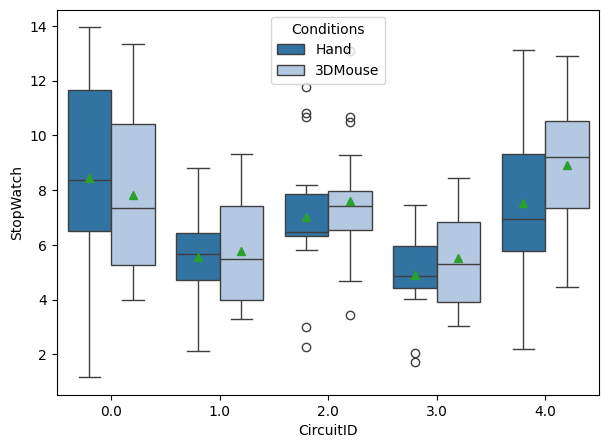

In [71]:
f,ax = plt.subplots(1,1, figsize=(7, 5))
hue_order = ['Hand', '3DMouse']
ax = sns.boxplot(data = allCountdowns,
            x = 'CircuitID',
            y = 'StopWatch', hue = 'Conditions',
            showmeans = True, palette = 'tab20', hue_order = hue_order)

f.savefig('./StopWatchPathTracing.pdf')

In [72]:
for k in range(0, len(conditions)):
    print(conditions[k])
    print(allCountdowns[(allCountdowns['UX'] == 'PathTracing') & (allCountdowns['Conditions'] == conditions[k])]['StopWatch'].describe())

Hand
count    70.000000
mean      6.604769
std       2.936466
min       1.164454
25%       4.830932
50%       6.345569
75%       8.080054
max      13.949080
Name: StopWatch, dtype: float64
3DMouse
count    86.000000
mean      7.087260
std       2.607956
min       3.045017
25%       4.873104
50%       6.868714
75%       8.701785
max      13.320020
Name: StopWatch, dtype: float64


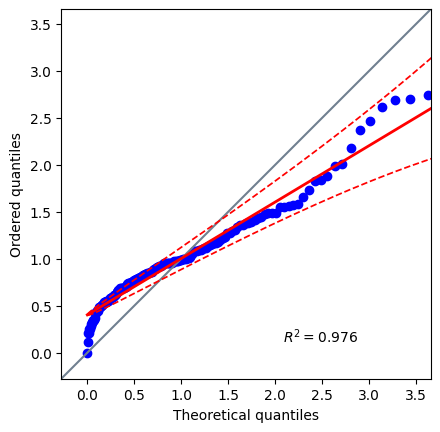

In [73]:
ax = pg.qqplot(realAccDistancePT['AccDistance'], dist='expon')

In [74]:
pg.rm_anova(data = realAccDistancePT, 
            dv = 'AccDistance', within = ['Conditions', 'CircuitID'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,449.931301,1,15,449.931301,4.525840,0.050384,0.050384,0.068625,1.000000
1,CircuitID,393.378586,4,60,98.344647,2.731134,0.037192,0.090603,0.060000,0.431651
2,Conditions * CircuitID,255.241967,4,60,63.810492,4.153704,0.004904,0.016941,0.038931,0.622594


In [75]:
for i in range(0, len(measureCircuit)):
    print(measureCircuit[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(realAccDistancePT[realAccDistancePT['CircuitID'] == measureCircuit[i]]['AccDistance'], groups = realAccDistancePT[realAccDistancePT['CircuitID'] == measureCircuit[i]]['Conditions'], alpha=0.05))


Circuit0
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
3DMouse   Hand   7.5737 0.0304 0.7618 14.3857   True
----------------------------------------------------
Circuit1
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand   1.2814 0.4521 -2.1444 4.7071  False
----------------------------------------------------
Circuit2
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand    3.766 0.0529 -0.0503 7.5823  False
----------------------------------------------------
Circuit3
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   

In [76]:
for i in range(0, len(measureCircuit)):
    for k in range(0, len(conditions)):
        print(measureCircuit[i], conditions[k])
        print(realAccDistancePT[(realAccDistancePT['Conditions'] == conditions[k]) & (realAccDistancePT['CircuitID'] == measureCircuit[i])]['AccDistance'].describe())

Circuit0 Hand
count    17.000000
mean     23.295416
std       9.743663
min      13.426115
25%      16.062428
50%      20.881858
75%      25.205683
max      48.898314
Name: AccDistance, dtype: float64
Circuit0 3DMouse
count    18.000000
mean     15.721674
std      10.045095
min       6.168919
25%      10.231973
50%      12.018795
75%      17.308953
max      40.672977
Name: AccDistance, dtype: float64
Circuit1 Hand
count    17.000000
mean     17.652947
std       5.549825
min      11.454668
25%      14.488087
50%      17.073568
75%      18.473218
max      35.242364
Name: AccDistance, dtype: float64
Circuit1 3DMouse
count    18.000000
mean     16.371551
std       4.373712
min       9.688960
25%      12.523735
50%      16.443908
75%      18.429570
max      25.488701
Name: AccDistance, dtype: float64
Circuit2 Hand
count    17.000000
mean     19.773927
std       6.836679
min      12.876724
25%      15.637595
50%      17.638921
75%      20.385152
max      38.225049
Name: AccDistance, dtype: fl

In [77]:
allCircuits.head()

,BlockID,Frame,StopWatch,PosX,PosY,PosZ,User,Conditions,CircuitID,UX,PositionAbsolute,PositionSubstraction
0,0,1,0.049927,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
1,0,3,0.084286,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
2,0,4,0.101349,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
3,0,5,0.120125,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
4,0,6,0.139626,1.7021,0.616,-2.852,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0


In [78]:
allCircuits

,BlockID,Frame,StopWatch,PosX,PosY,PosZ,User,Conditions,CircuitID,UX,PositionAbsolute,PositionSubstraction
0,0,1,0.049927,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
1,0,3,0.084286,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
2,0,4,0.101349,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
3,0,5,0.120125,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
4,0,6,0.139626,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
420,0,421,11.153930,2.5052,0.6032,-1.1463,User1,Hand,Circuit0,PathTracing,2.820263,0.0
421,0,422,11.178200,2.5052,0.6032,-1.1463,User1,Hand,Circuit0,PathTracing,2.820263,0.0
422,0,423,11.206400,2.5225,0.5772,-1.2943,User1,Hand,Circuit0,PathTracing,2.893333,0.0
423,0,424,11.235190,2.5860,0.6603,-1.1526,User1,Hand,Circuit0,PathTracing,2.907212,0.0


In [79]:
import matplotlib.animation as animation
import matplotlib
from mpl_toolkits.mplot3d import Axes3D

In [109]:
trajectoryCircuit0X = [2.2, 2.2, 2.2, 2.2, -2.8]
trajectoryCircuit0Y = [0, 0, 0, 0, 0]
trajectoryCircuit0Z = [-3.5, -3.0, -2.8, 2.64, 2.64]

trajectoryCircuit0Xc = [2.2, 2.2, 2.2, 2.2, -2.8]
trajectoryCircuit0Yc = [0.78, 0.78, 0.78, 0.78, 0.78]
trajectoryCircuit0Zc = [-3.5, -3.0, -2.8, 2.64, 2.64]

trajectoryCircuit0Xd = [2.2, 2.2, 2.2, 2.2, -2.8]
trajectoryCircuit0Yd = [-0.3, -0.3, -0.3, -0.3, -0.3]
trajectoryCircuit0Zd = [-3.5, -3.0, -2.8, 2.64, 2.64]

trajectoryCircuit0Xa = [2.73, 2.73, -2.8]
trajectoryCircuit0Ya = [0, 0, 0]
trajectoryCircuit0Za = [-3.5, 3.2,  3.2]

trajectoryCircuit0Xb = [1.6,  1.6,  -2.8]
trajectoryCircuit0Yb = [0, 0, 0]
trajectoryCircuit0Zb = [-3.5, 1.95, 1.95]

trajectoryCircuit1X = [-2.8, 2.95]
trajectoryCircuit1Y = [0.15, 0.15]
trajectoryCircuit1Z = [-1.3, 2.15]

trajectoryCircuit2X = [2.7, -1.75, -2.0, -2.25, -2.25, -1.75, 2.7]
trajectoryCircuit2Y = [0.2, 0.2, 0.2, 0.2,  0.2, 0.2, 0.2]
trajectoryCircuit2Z = [-1.7, -1.7, -1.7, -1.15, 1.4, 2.0, 2.0]

trajectoryCircuit3X = [-2.9, 3.15]
trajectoryCircuit3Y = [0.65, -0.74]
trajectoryCircuit3Z = [-1.35, 2.1]

trajectoryCircuit4X = [1.72, 1.72, 1.36, -1.84, -2.66, -2.66, -2.66, -2.2, -0.05, 3.3]
trajectoryCircuit4Y = [0.63, 0.63, 0.63, 0.46, 0.46, 0.3, 0.22, 0.12, -0.55, -0.75]
trajectoryCircuit4Z = [-2.8, -1.54, -1.0, -1.0, -0.3, 0.9, 1.36, 1.5, 1.9, 2.0]

from scipy import interpolate

from scipy.interpolate import interp2d



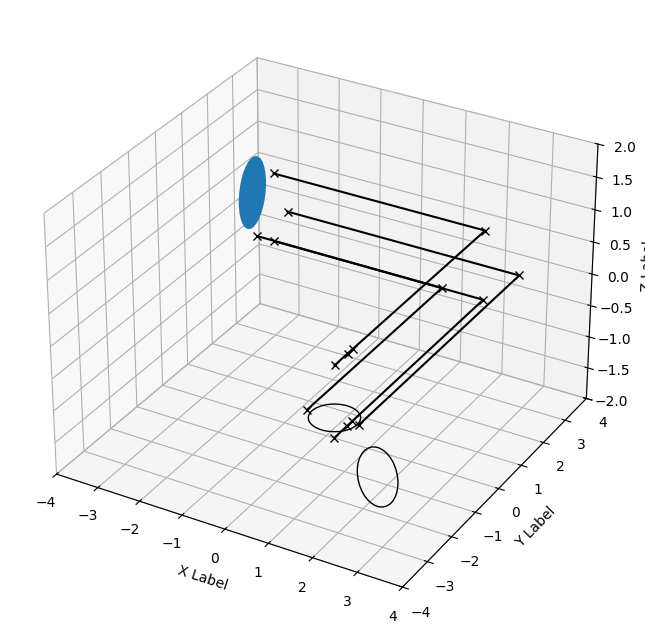

In [251]:
fig = plt.figure(figsize=(20, 8))



#for i in range(0, len(conditions)):
for j in range(0, 1):
    ax = fig.add_subplot(121, projection='3d')

    ax.plot(trajectoryCircuit0Xa, trajectoryCircuit0Za, trajectoryCircuit0Ya, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xb, trajectoryCircuit0Zb, trajectoryCircuit0Yb, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xc, trajectoryCircuit0Zc, trajectoryCircuit0Yc, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xd, trajectoryCircuit0Zd, trajectoryCircuit0Yd, label = 'Target', marker = 'x', color = 'black')

    
    p = Circle((trajectoryCircuit0X[len(trajectoryCircuit0X)-1], trajectoryCircuit0Z[len(trajectoryCircuit0X)-1]), 0.5)
    ax.add_patch(p)
    art3d.pathpatch_2d_to_3d(p, z=trajectoryCircuit0Y[0], zdir="x")

    p = Circle((trajectoryCircuit0X[0], trajectoryCircuit0Z[0]), 0.5, fill = False)
    ax.add_patch(p)
    art3d.pathpatch_2d_to_3d(p, z=trajectoryCircuit0Y[0], zdir="z")


    p = Circle((-trajectoryCircuit0Y[0], trajectoryCircuit0Z[0]), 0.5, fill = False)
    ax.add_patch(p)
    art3d.pathpatch_2d_to_3d(p, z=trajectoryCircuit0X[0], zdir="y")
       

    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')



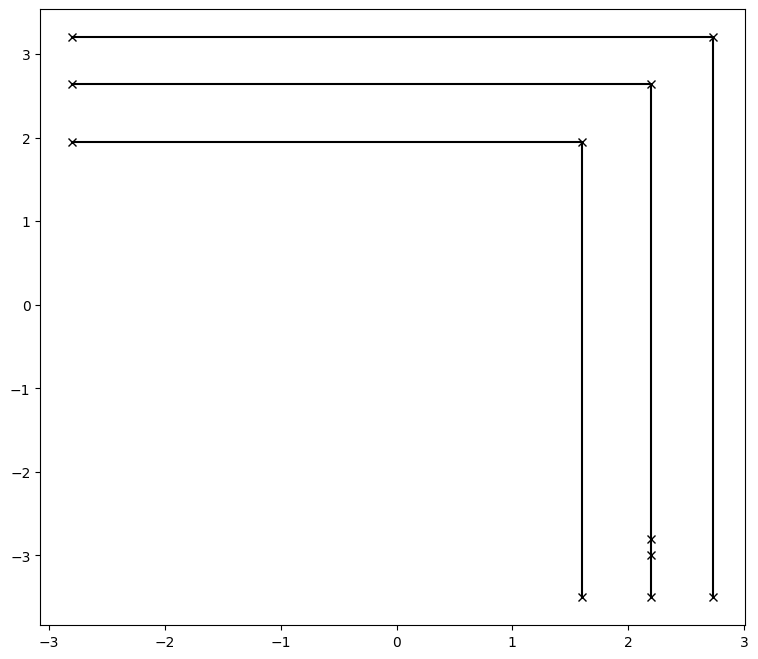

In [106]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)
ax.plot(trajectoryCircuit0X, trajectoryCircuit0Z, label = 'Target', marker = 'x', color = 'black')
ax.plot(trajectoryCircuit0X1a, trajectoryCircuit0Z1a, label = 'Target', marker = 'x', color = 'black')
ax.plot(trajectoryCircuit0X1b, trajectoryCircuit0Z1b, label = 'Target', marker = 'x', color = 'black')


In [107]:
#func = interp2d(trajectoryCircuit1X, trajectoryCircuit1Z, trajectoryCircuit1Y)


<class 'float'>
127


Text(0.5, 0, 'Z Label')

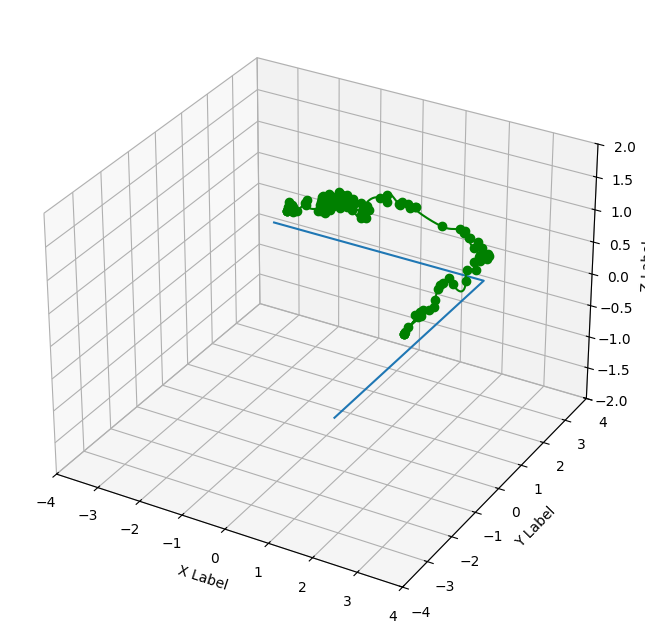

In [192]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit0X, trajectoryCircuit0Z, trajectoryCircuit0Y, label = 'Target')


# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-4, 4), ylabel='Y')
ax.set(zlim3d=(-2, 2), zlabel='Z')
 
cond = (allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[0])
print(type(allCircuits[cond]['PosX'].values.tolist()[0]))
 
num_true_pts = len(allCircuits[cond]['PosX'].values.tolist())
Xpart=[allCircuits[cond]['PosX'].values.tolist()[0]]
Ypart=[allCircuits[cond]['PosY'].values.tolist()[0]]
Zpart=[allCircuits[cond]['PosZ'].values.tolist()[0]]
for i in range(num_true_pts-1):
    if allCircuits[cond]['PosX'].values.tolist()[i+1]!=Xpart[-1] and allCircuits[cond]['PosY'].values.tolist()[i+1]!=Ypart[-1] and allCircuits[cond]['PosZ'].values.tolist()[i+1]!=Zpart[-1]:
        Xpart.append(allCircuits[cond]['PosX'].values.tolist()[i+1])
        Ypart.append(allCircuits[cond]['PosY'].values.tolist()[i+1])
        Zpart.append(allCircuits[cond]['PosZ'].values.tolist()[i+1])
 
num_true_pts=len(Xpart)
print(num_true_pts)
tck, u = interpolate.splprep([Xpart, Zpart, Ypart], s=0, k=min(num_true_pts-1, 3))
x_knots, y_knots, z_knots = interpolate.splev(tck[0], tck)
u_fine = np.linspace(0,1,num_true_pts*100)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)
 
ax.plot(x_knots, y_knots, z_knots, 'go')
ax.plot(x_fine, y_fine, z_fine, 'g')
 
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

In [186]:
discretizedTrajectoryX=[]
discretizedTrajectoryY=[]
discretizedTrajectoryZ=[]
num_points_per_line=10
for i in range(len(trajectoryCircuit0X)-1):
    if trajectoryCircuit0X[i]==trajectoryCircuit0X[i+1]:
        discretizedTrajectoryX.append(trajectoryCircuit0X[i])
    else:
        discretizedTrajectoryX.append(np.linspace(trajectoryCircuit0X[i], trajectoryCircuit0X[i+1],num_points_per_line))
    if trajectoryCircuit0Y[i]==trajectoryCircuit0Y[i+1]:
        discretizedTrajectoryY.append(trajectoryCircuit0Y[i])
    else:
        discretizedTrajectoryY.append(np.linspace(trajectoryCircuit0Y[i], trajectoryCircuit0Y[i+1],num_points_per_line))
    if trajectoryCircuit0Z[i]==trajectoryCircuit0Z[i+1]:
        discretizedTrajectoryZ.append(trajectoryCircuit0Z[i])
    else:
        discretizedTrajectoryZ.append(np.linspace(trajectoryCircuit0Z[i], trajectoryCircuit0Z[i+1],num_points_per_line))

In [187]:
discretizedTrajectoryX

[2.2,
 2.2,
 2.2,
 array([ 2.2       ,  1.64444444,  1.08888889,  0.53333333, -0.02222222,
        -0.57777778, -1.13333333, -1.68888889, -2.24444444, -2.8       ])]

In [188]:
discretizedTrajectoryY

[0, 0, 0, 0]

In [189]:

discretizedTrajectoryZ

[array([-3.5       , -3.44444444, -3.38888889, -3.33333333, -3.27777778,
        -3.22222222, -3.16666667, -3.11111111, -3.05555556, -3.        ]),
 array([-3.        , -2.97777778, -2.95555556, -2.93333333, -2.91111111,
        -2.88888889, -2.86666667, -2.84444444, -2.82222222, -2.8       ]),
 array([-2.8       , -2.19555556, -1.59111111, -0.98666667, -0.38222222,
         0.22222222,  0.82666667,  1.43111111,  2.03555556,  2.64      ]),
 2.64]

Text(0.5, 0, 'Z Label')

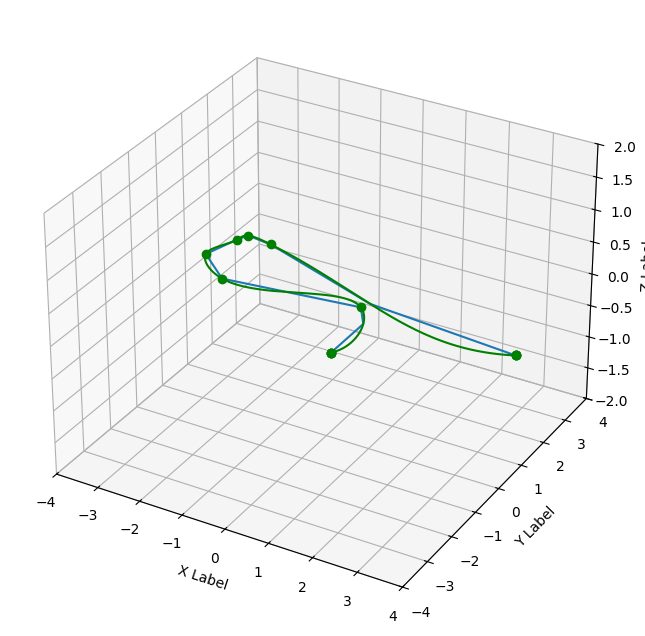

In [82]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit4X, trajectoryCircuit4Z, trajectoryCircuit4Y, label = 'Target')
    
# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-4, 4), ylabel='Y')
ax.set(zlim3d=(-2, 2), zlabel='Z')

num_true_pts = 200
tck, u = interpolate.splprep([trajectoryCircuit4X,trajectoryCircuit4Z,trajectoryCircuit4Y], s=0)
x_knots, y_knots, z_knots = interpolate.splev(tck[0], tck)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.plot(x_knots, y_knots, z_knots, 'go')
ax.plot(x_fine, y_fine, z_fine, 'g')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

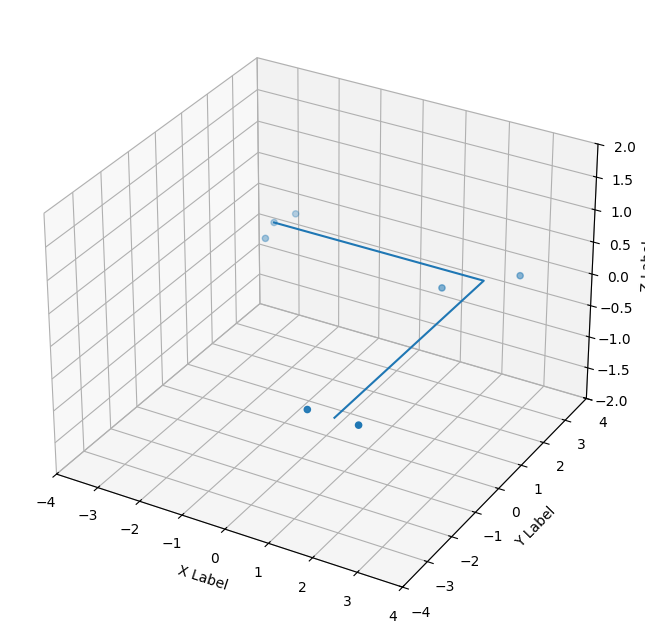

In [83]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit0X, trajectoryCircuit0Z, trajectoryCircuit0Y, label = 'Target')
ax.scatter(trajectoryCircuit0X1, trajectoryCircuit0Z1, trajectoryCircuit0Y1)
    
# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-4, 4), ylabel='Y')
ax.set(zlim3d=(-2, 2), zlabel='Z')


ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')


Text(0.5, 0, 'Z Label')

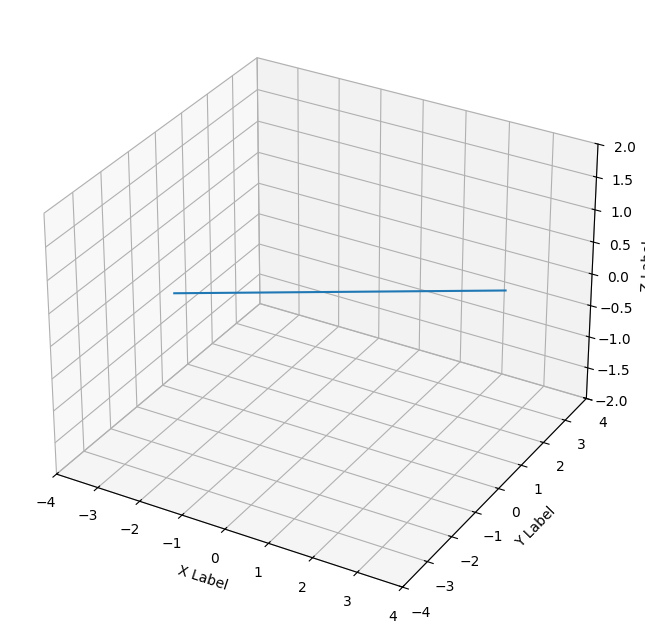

In [84]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit1X, trajectoryCircuit1Z, trajectoryCircuit1Y, label = 'Target')
    
# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-4, 4), ylabel='Y')
ax.set(zlim3d=(-2, 2), zlabel='Z')


ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

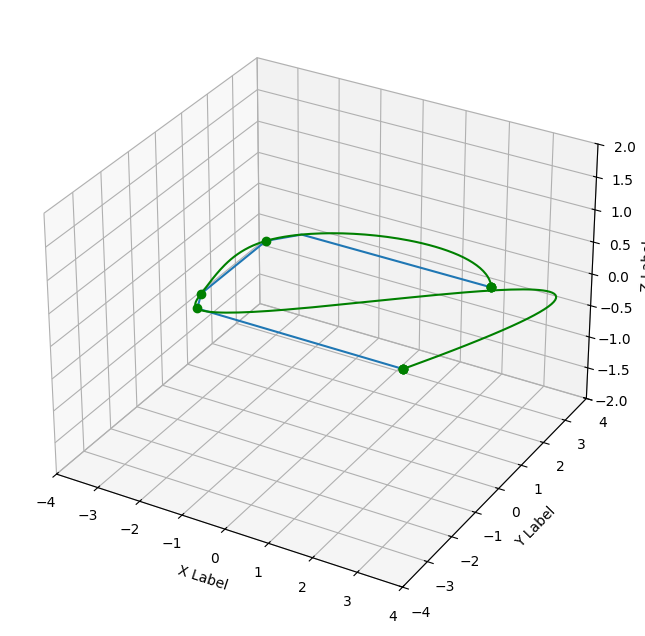

In [85]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit2X, trajectoryCircuit2Z, trajectoryCircuit2Y, label = 'Target')
    
# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-4, 4), ylabel='Y')
ax.set(zlim3d=(-2, 2), zlabel='Z')

num_true_pts = 200
tck, u = interpolate.splprep([trajectoryCircuit2X,trajectoryCircuit2Z,trajectoryCircuit2Y], s = 0)
x_knots, y_knots, z_knots = interpolate.splev(tck[0], tck)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.plot(x_knots, y_knots, z_knots, 'go')
ax.plot(x_fine, y_fine, z_fine, 'g')



ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

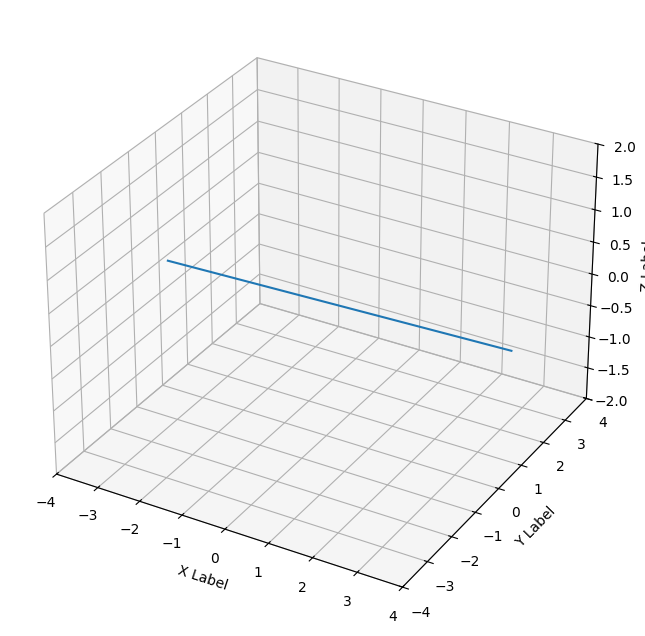

In [108]:
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit3X, trajectoryCircuit3Z, trajectoryCircuit3Y, label = 'Target')
    
# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-4, 4), ylabel='Y')
ax.set(zlim3d=(-2, 2), zlabel='Z')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')


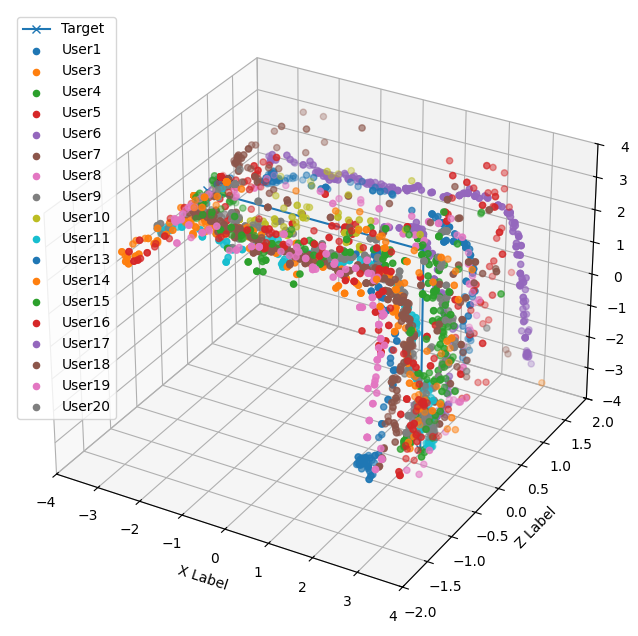

In [83]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(trajectoryCircuit0X, trajectoryCircuit0Y, trajectoryCircuit0Z, label = 'Target', marker = 'x')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    ax.legend()

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-2, 2), ylabel='Z')
    ax.set(zlim3d=(-4, 4), zlabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Z Label')
    ax.set_zlabel('Y Label')


plt.show()

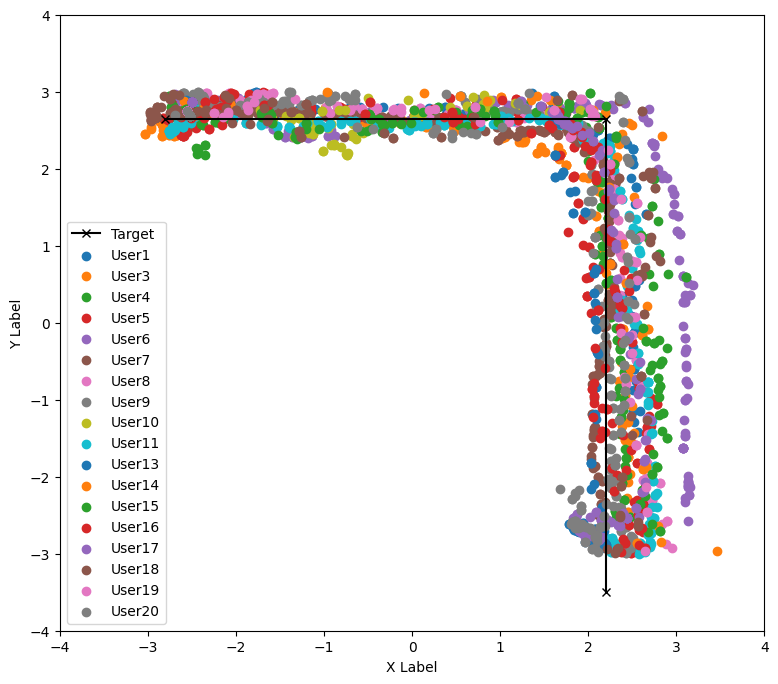

In [1115]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)
ax.plot(trajectoryCircuit0X, trajectoryCircuit0Z, label = 'Target', marker = 'x', color = 'black')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')


plt.show()


In [114]:

from matplotlib.patches import Circle, PathPatch
import mpl_toolkits.mplot3d.art3d as art3d


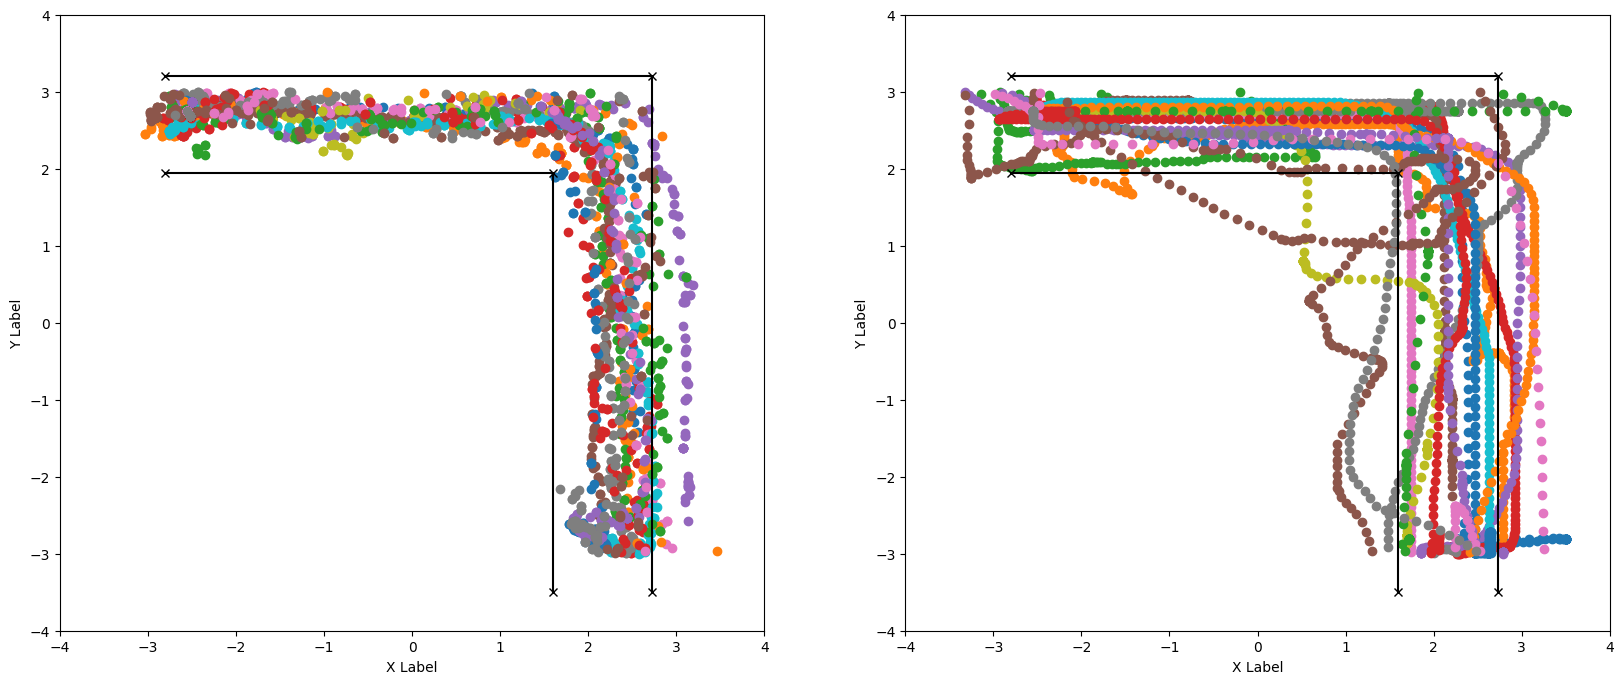

In [104]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)
#ax.plot(trajectoryCircuit0X, trajectoryCircuit0Z, label = 'Target', marker = 'x', color = 'black')
ax.plot(trajectoryCircuit0X1a, trajectoryCircuit0Z1a, label = 'Target', marker = 'x', color = 'black')
ax.plot(trajectoryCircuit0X1b, trajectoryCircuit0Z1b, label = 'Target', marker = 'x', color = 'black')


for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

ax = fig.add_subplot(1, 2, 2)

ax.plot(trajectoryCircuit0X1a, trajectoryCircuit0Z1a, label = 'Target', marker = 'x', color = 'black')
ax.plot(trajectoryCircuit0X1b, trajectoryCircuit0Z1b, label = 'Target', marker = 'x', color = 'black')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

plt.savefig('./Circuit0.pdf')

plt.show()

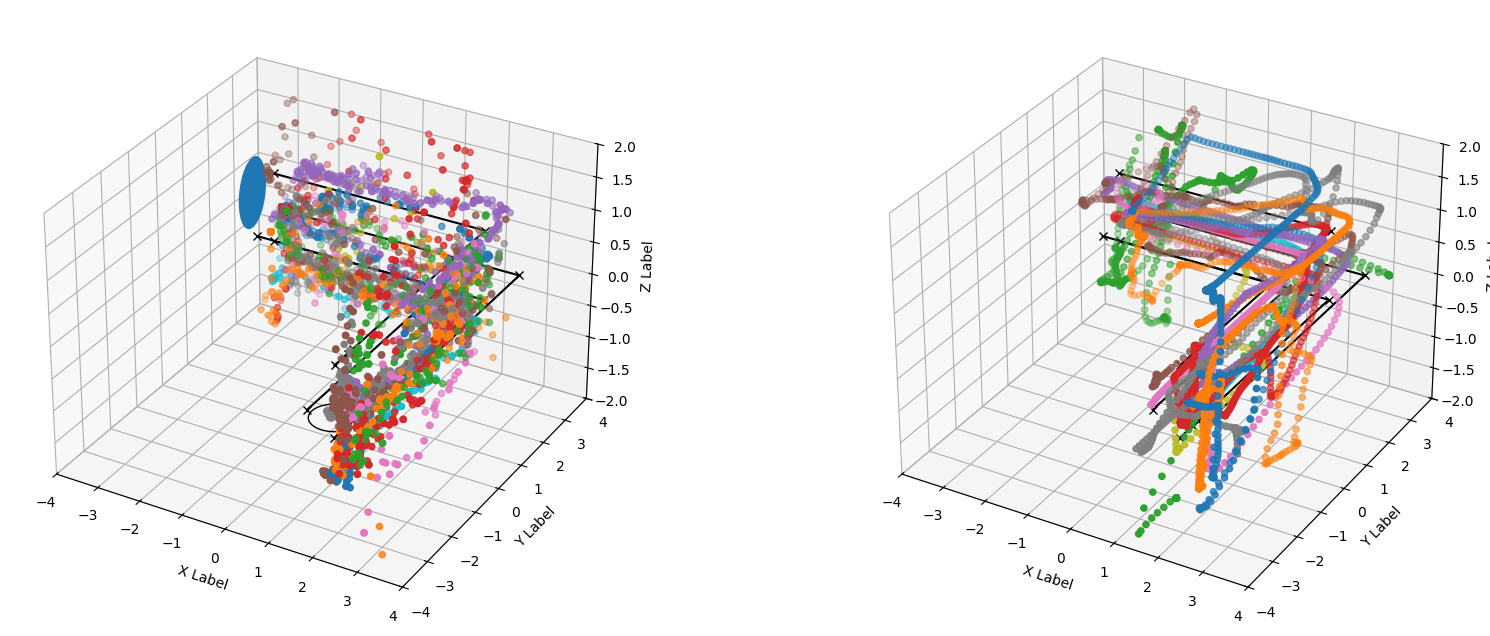

In [158]:
fig = plt.figure(figsize=(20, 8))



#for i in range(0, len(conditions)):
for j in range(0, 1):
    ax = fig.add_subplot(121, projection='3d')

    ax.plot(trajectoryCircuit0Xa, trajectoryCircuit0Za, trajectoryCircuit0Ya, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xb, trajectoryCircuit0Zb, trajectoryCircuit0Yb, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xc, trajectoryCircuit0Zc, trajectoryCircuit0Yc, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xd, trajectoryCircuit0Zd, trajectoryCircuit0Yd, label = 'Target', marker = 'x', color = 'black')

    
    p = Circle((trajectoryCircuit0X[len(trajectoryCircuit0X)-1], trajectoryCircuit0Z[len(trajectoryCircuit0X)-1]), 0.5)
    ax.add_patch(p)
    art3d.pathpatch_2d_to_3d(p, z=0, zdir="x")

    p = Circle((trajectoryCircuit0X[0], trajectoryCircuit0Z[0]), 0.5, fill = False)
    ax.add_patch(p)
    art3d.pathpatch_2d_to_3d(p, z=0, zdir="z")
    
       
    for k in range(0, len(nameList)):
        cond =  (allCircuits['CircuitID'] == measureCircuit[j]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k])
    
        ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])
        # Setting the Axes properties
        ax.set(xlim3d=(-4, 4), xlabel='X')
        ax.set(ylim3d=(-4, 4), ylabel='Y')
        ax.set(zlim3d=(-2, 2), zlabel='Z')
        
        ax.set_xlabel('X Label')
        ax.set_ylabel('Y Label')
        ax.set_zlabel('Z Label')

    ax = fig.add_subplot(122, projection='3d')
    
    ax.plot(trajectoryCircuit0Xa, trajectoryCircuit0Za, trajectoryCircuit0Ya, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xb, trajectoryCircuit0Zb, trajectoryCircuit0Yb, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xc, trajectoryCircuit0Zc, trajectoryCircuit0Yc, label = 'Target', marker = 'x', color = 'black')
    ax.plot(trajectoryCircuit0Xd, trajectoryCircuit0Zd, trajectoryCircuit0Yd, label = 'Target', marker = 'x', color = 'black')

    for k in range(0, len(nameList)):
        cond =  (allCircuits['CircuitID'] == measureCircuit[j]) & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) 

        ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])
    
        # Setting the Axes properties
        ax.set(xlim3d=(-4, 4), xlabel='X')
        ax.set(ylim3d=(-4, 4), ylabel='Y')
        ax.set(zlim3d=(-2, 2), zlabel='Z')
        
        ax.set_xlabel('X Label')
        ax.set_ylabel('Y Label')
        ax.set_zlabel('Z Label')

plt.savefig('./Circuit0-3d.pdf')
plt.show()


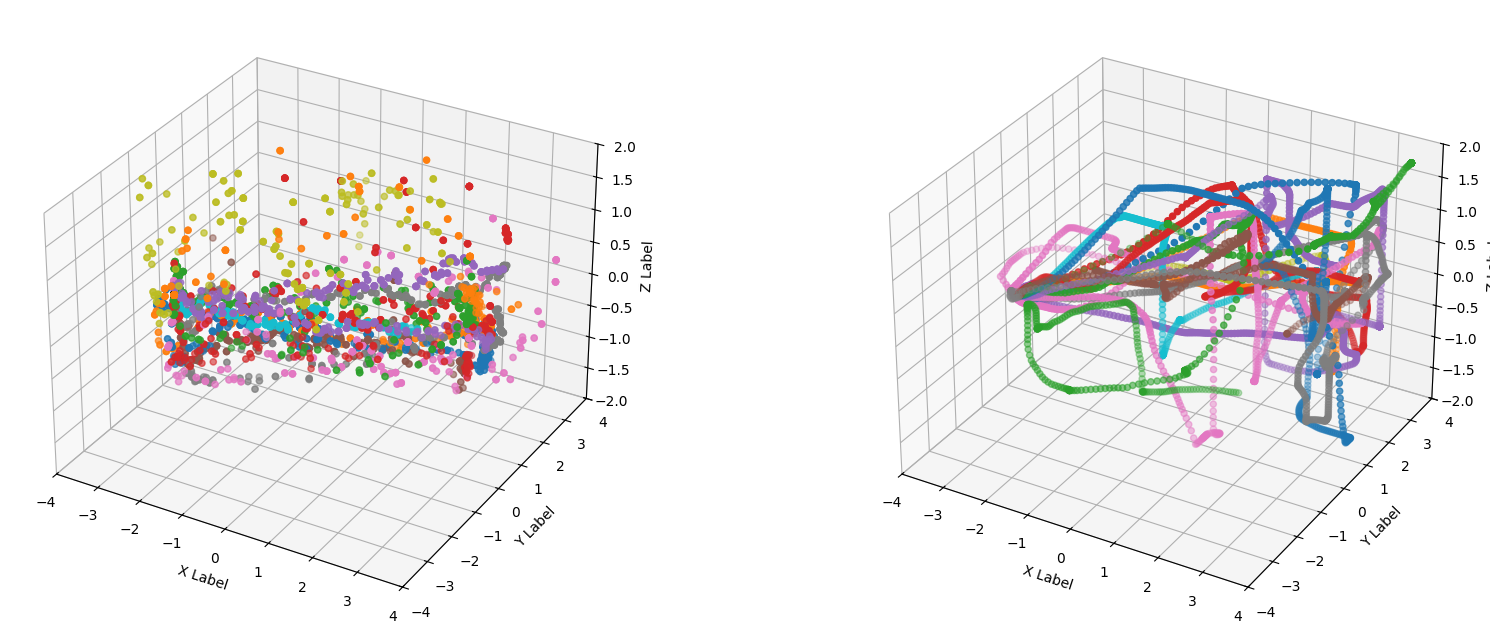

In [1153]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121, projection='3d')
weirdList = ['User10', 'User16', 'User12']

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit1') & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k])

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

ax = fig.add_subplot(122, projection='3d')

for k in range(0, len(nameList)):
    cond =  (allCircuits['CircuitID'] == 'Circuit1') & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

plt.savefig('./Circuit1-3d.pdf')
plt.show()


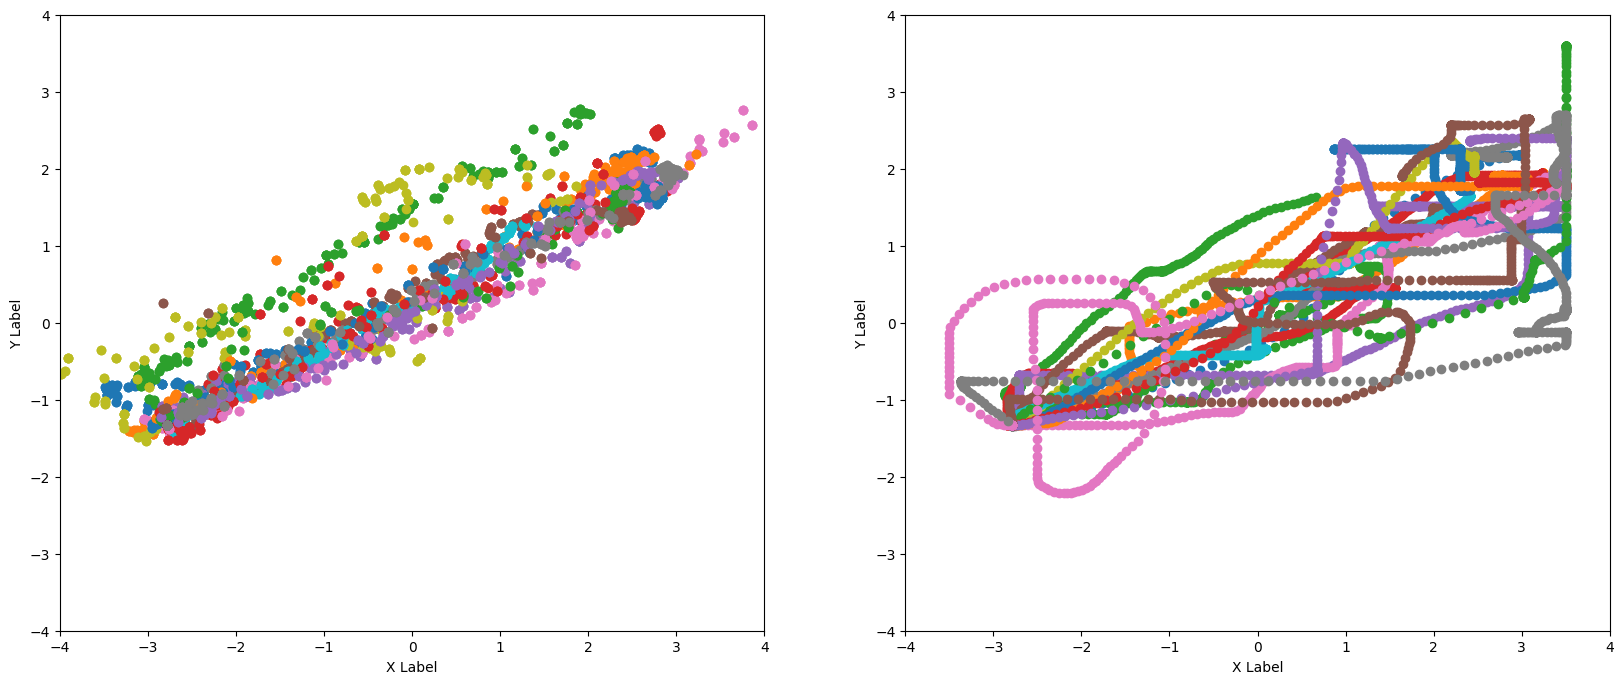

In [1158]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[1]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

ax = fig.add_subplot(1, 2, 2)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[1]) & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

plt.savefig('./Circuit1.pdf')
plt.show()

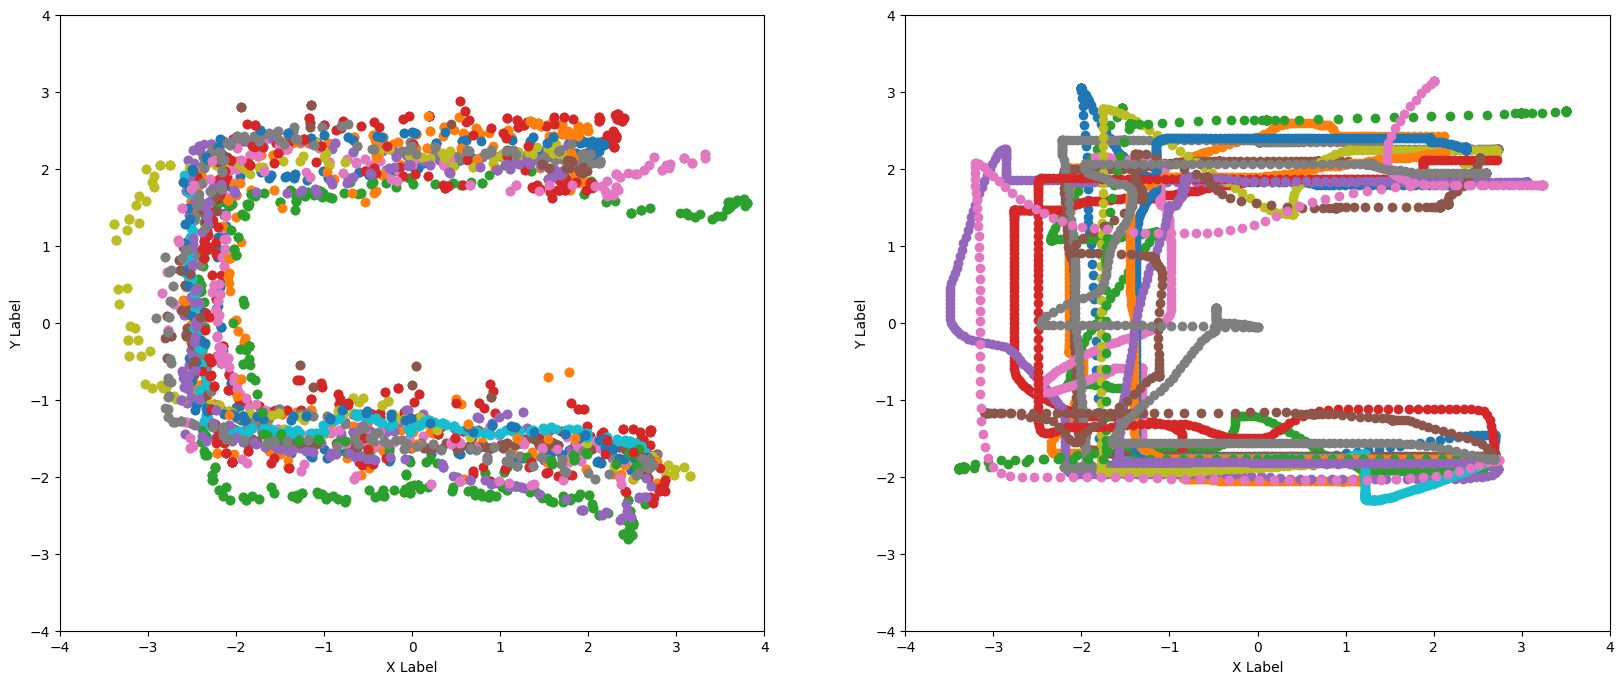

In [1159]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[2]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

ax = fig.add_subplot(1, 2, 2)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[2]) & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k])

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

plt.savefig('./Circuit2.pdf')

plt.show()

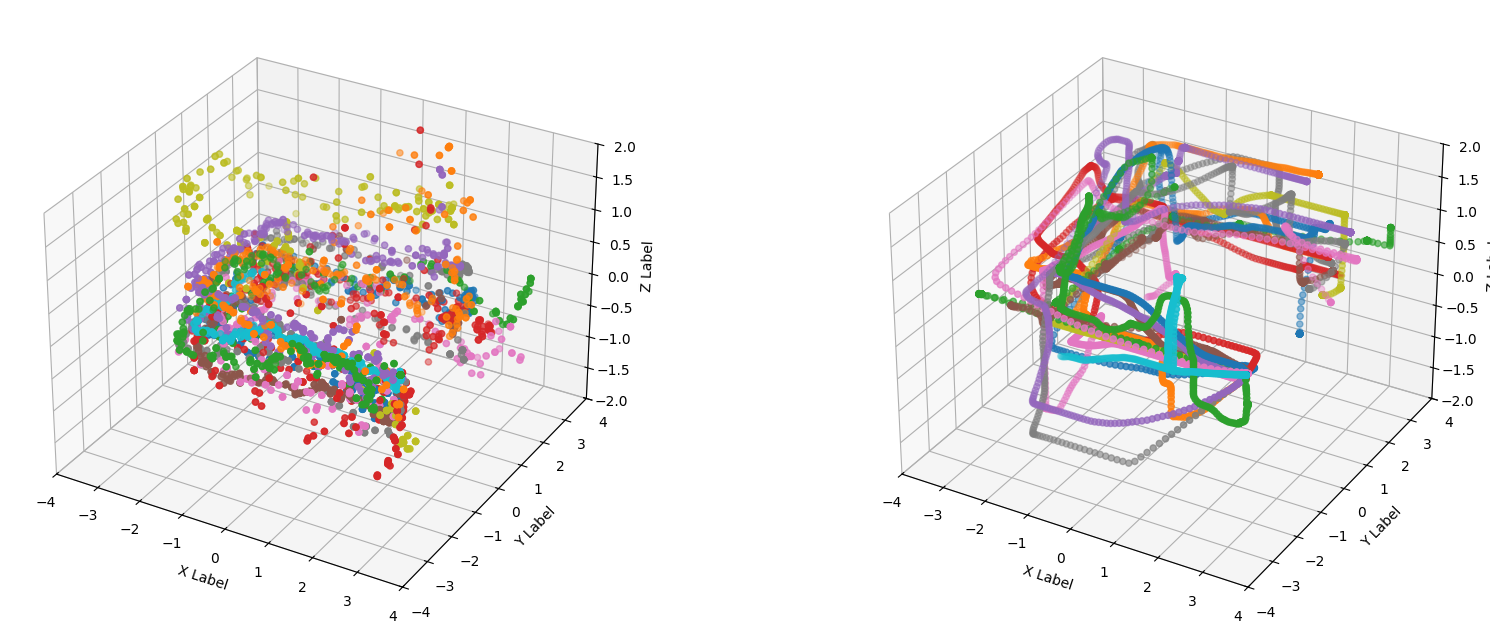

In [1156]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121, projection='3d')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit2') & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k])

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

ax = fig.add_subplot(122, projection='3d')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit2') & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k])

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

plt.savefig('./Circuit2-3d.pdf')

plt.show()


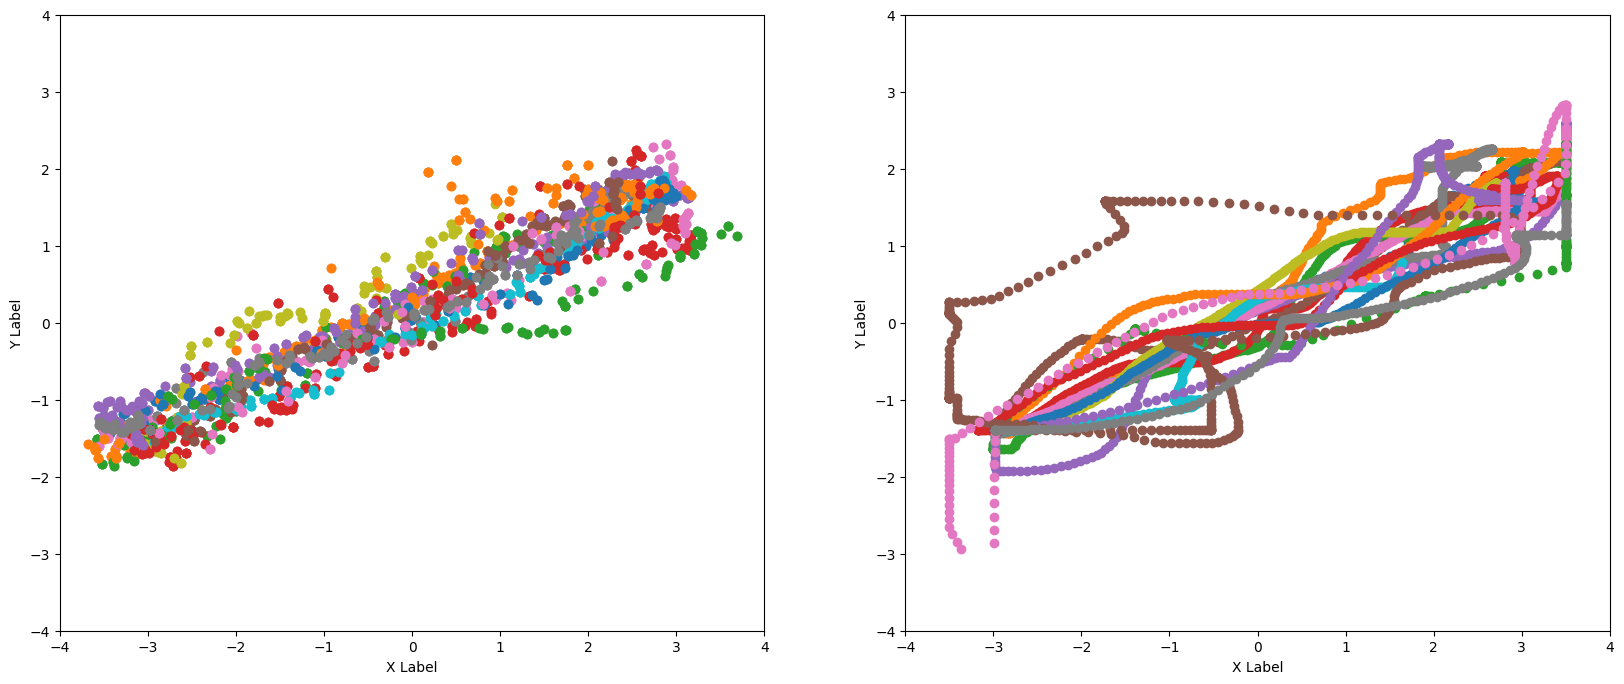

In [1160]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[3]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

ax = fig.add_subplot(1, 2, 2)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[3]) & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

plt.savefig('./Circuit3.pdf')

plt.show()

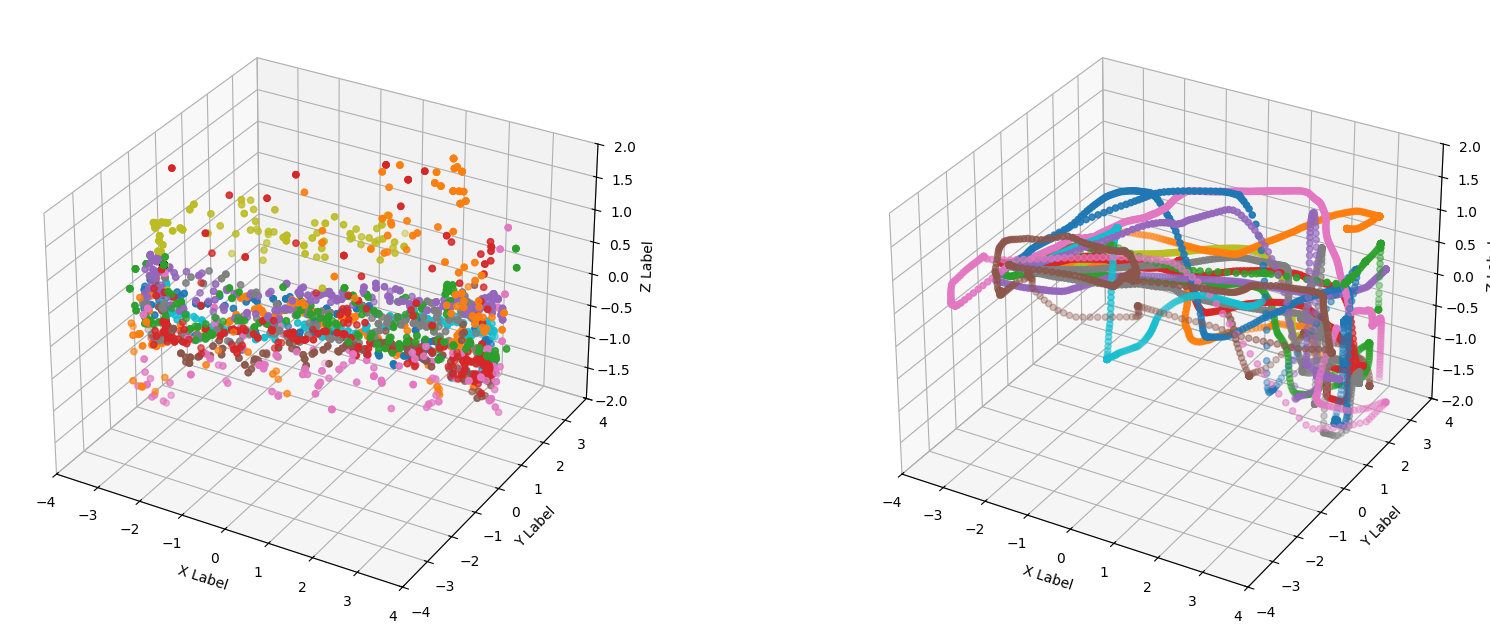

In [1152]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121, projection='3d')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit3') & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k])

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

ax = fig.add_subplot(122, projection='3d')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit3') & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

plt.savefig('./Circuit3-3d.pdf')
plt.show()


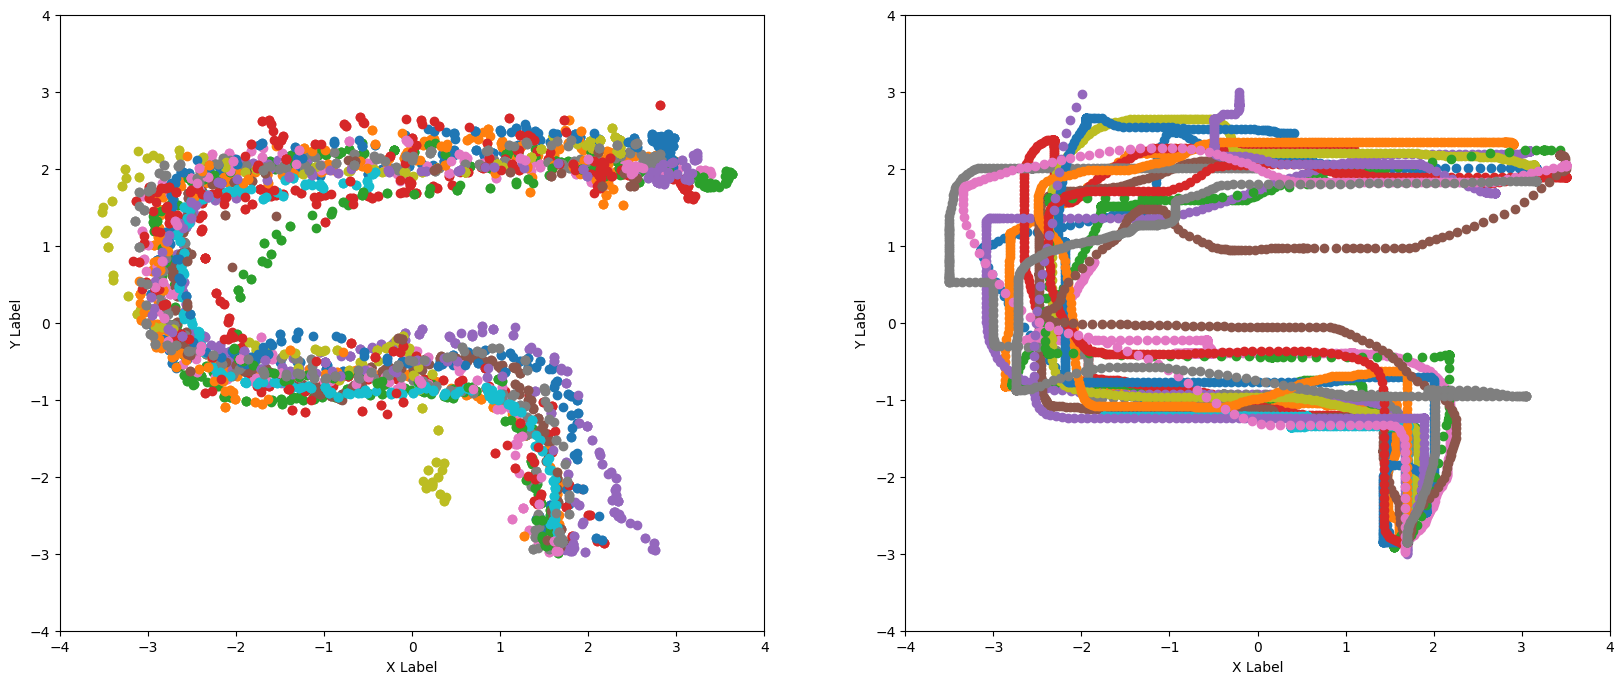

In [1161]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(1, 2, 1)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[4]) & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

ax = fig.add_subplot(1, 2, 2)

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == measureCircuit[4]) & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[k])
    #ax.legend()

    # Setting the Axes properties
    ax.set(xlim=(-4, 4), xlabel='X')
    ax.set(ylim=(-4, 4), ylabel='Y')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')

plt.savefig('./Circuit4.pdf')

plt.show()

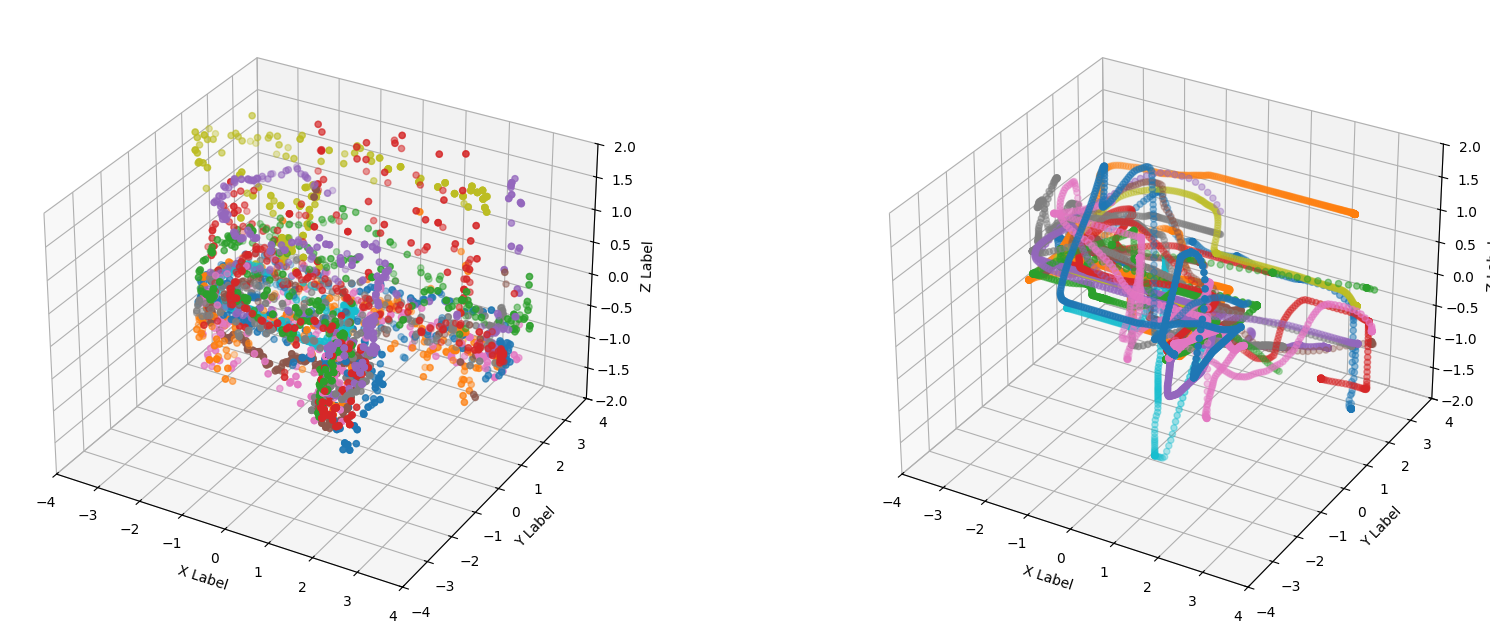

In [1150]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121, projection='3d')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit4') & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k])

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

ax = fig.add_subplot(122, projection='3d')

for k in range(0, len(nameList)):
    cond = (allCircuits['CircuitID'] == 'Circuit4') & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) 

    ax.scatter(allCircuits[cond]['PosX'], allCircuits[cond]['PosZ'], allCircuits[cond]['PosY'], label = nameList[k])

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-4, 4), ylabel='Y')
    ax.set(zlim3d=(-2, 2), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

plt.savefig('./Circuit4-3d.pdf')
plt.show()

## Remove the shitty conditiosn for AccDistance

In [601]:
pg.rm_anova(data = allCountdowns[allCountdowns['UX'] == 'PathTracing'], 
            dv = 'AccDistance', within = ['Conditions'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')


,Source,SS,DF,MS,F,p-unc,n2,eps
0,Conditions,3.280847,1,3.280847,14.154034,0.001703,0.366658,1.0
1,Error,3.708734,16,0.231796,NaN,NaN,NaN,NaN


In [602]:

allCountdowns[(allCountdowns['UX'] == 'PathTracing') & (allCountdowns['Conditions'] == 'Hand')]['AccDistance'].describe()

count    70.000000
mean      2.059195
std       0.602914
min       1.019985
25%       1.631523
50%       2.056839
75%       2.484353
max       3.384289
Name: AccDistance, dtype: float64

In [603]:
allCountdowns[(allCountdowns['UX'] == 'PathTracing') & (allCountdowns['Conditions'] == '3DMouse')]['AccDistance'].describe()


count    86.000000
mean      1.550461
std       0.507169
min       0.721101
25%       1.121637
50%       1.525080
75%       1.837112
max       3.240855
Name: AccDistance, dtype: float64

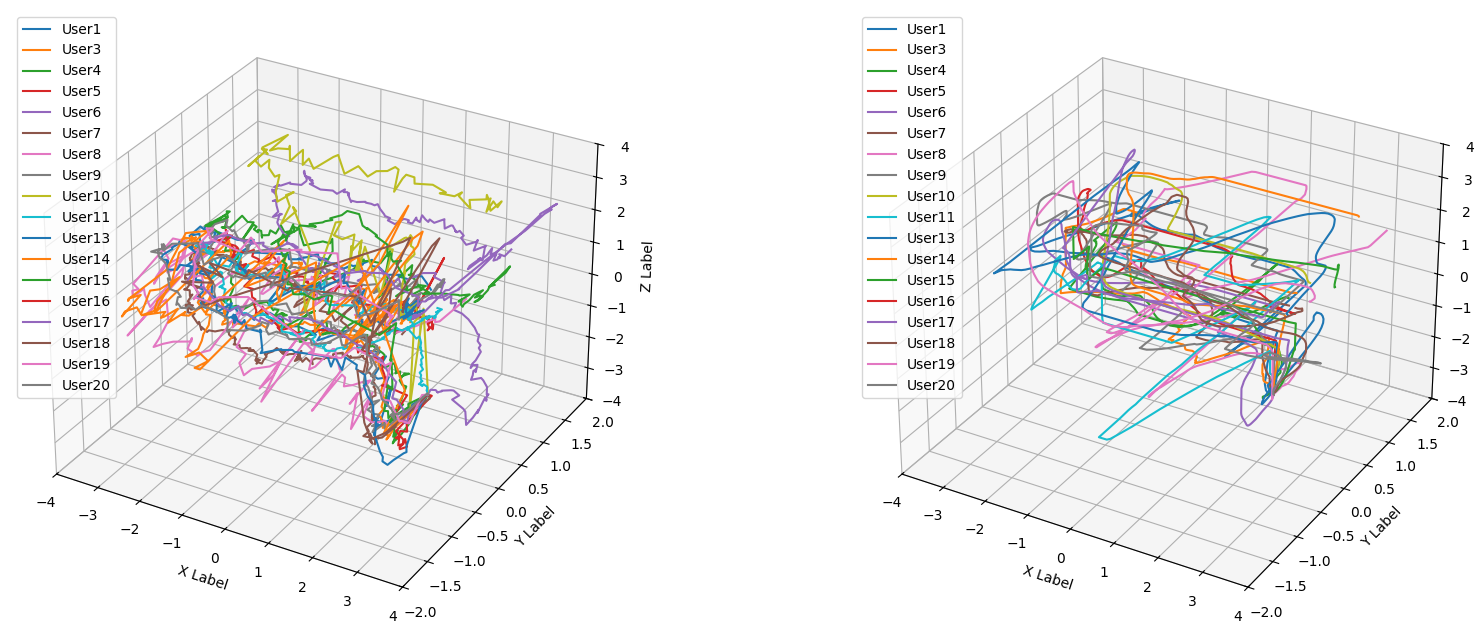

In [604]:
fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(121, projection='3d')

for k in range(0, len(nameList)):
    cond =  (allCircuits['User'] != 'User16') & (allCircuits['User'] != 'User12') & (allCircuits['CircuitID'] == 'Circuit4') & (allCircuits['Conditions'] == conditions[0]) & (allCircuits['User'] == nameList[k]) 

    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], label = nameList[k])
    ax.legend()

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-2, 2), ylabel='Y')
    ax.set(zlim3d=(-4, 4), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')

ax = fig.add_subplot(122, projection='3d')

for k in range(0, len(nameList)):
    cond =  (allCircuits['User'] != 'User16') & (allCircuits['User'] != 'User12') & (allCircuits['CircuitID'] == 'Circuit4') & (allCircuits['Conditions'] == conditions[1]) & (allCircuits['User'] == nameList[k]) 
    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], label = nameList[k])
    ax.legend()

    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-2, 2), ylabel='Y')
    ax.set(zlim3d=(-4, 4), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
plt.show()


Text(0.5, 0, 'Z Label')

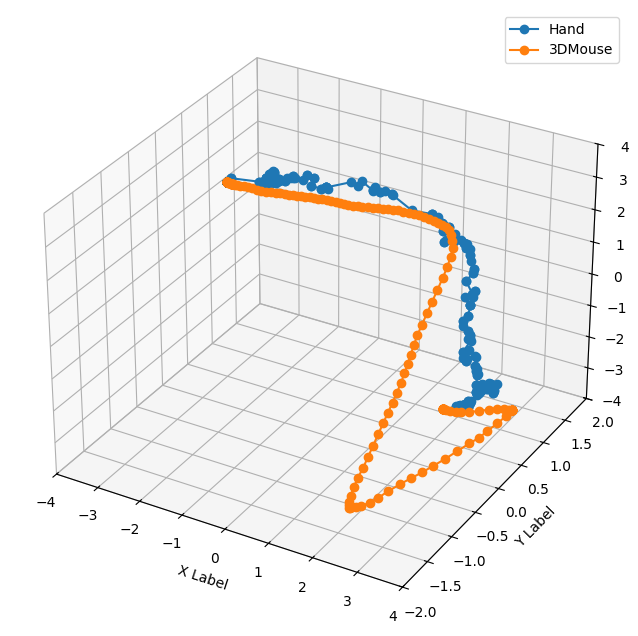

In [605]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(0, 2):
    cond = (allCircuits['CircuitID'] == measureCircuit[0]) & (allCircuits['Conditions'] == conditions[i]) & (allCircuits['User'] == nameList[0]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3)  & (allCircuits['User'] != 'User2')  & (allCircuits['User'] != 'User12') & (allCircuits['User'] != 'User18') 

    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = conditions[i])
    ax.legend()

# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-2, 2), ylabel='Y')
ax.set(zlim3d=(-4, 4), zlabel='Z')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

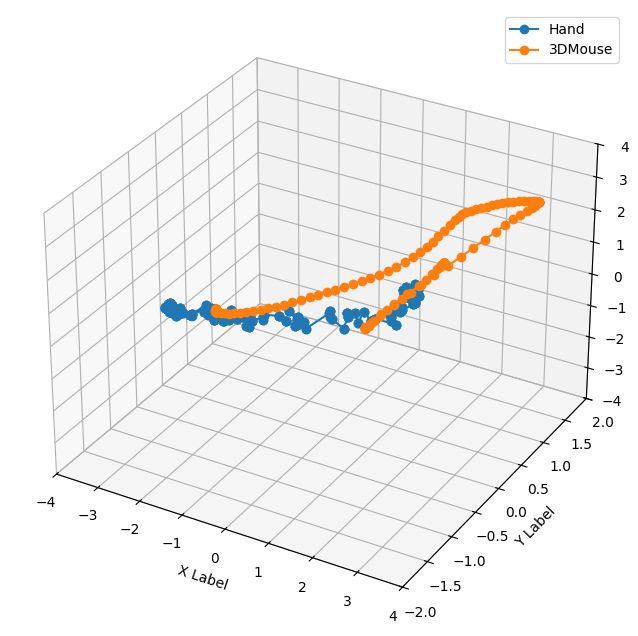

In [606]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(0, 2):
    cond = (allCircuits['CircuitID'] == measureCircuit[1]) & (allCircuits['Conditions'] == conditions[i]) & (allCircuits['User'] == nameList[0]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3)  & (allCircuits['User'] != 'User2')  & (allCircuits['User'] != 'User12') & (allCircuits['User'] != 'User18') 

    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = conditions[i])
    ax.legend()

# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-2, 2), ylabel='Y')
ax.set(zlim3d=(-4, 4), zlabel='Z')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

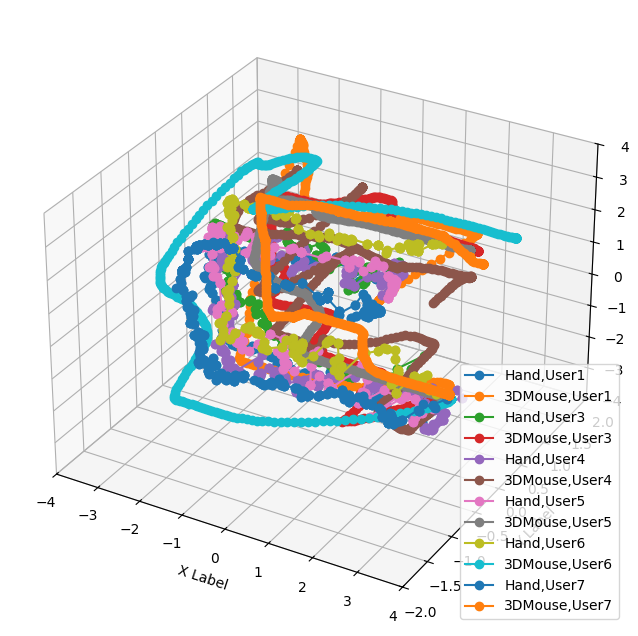

In [607]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for k in range(0, 6):
    for i in range(0, 2):
        cond = (allCircuits['CircuitID'] == measureCircuit[2]) & (allCircuits['Conditions'] == conditions[i]) & (allCircuits['User'] == nameList[k])  
    
        ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = conditions[i]+','+nameList[k])
        ax.legend()


# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-2, 2), ylabel='Y')
ax.set(zlim3d=(-4, 4), zlabel='Z')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

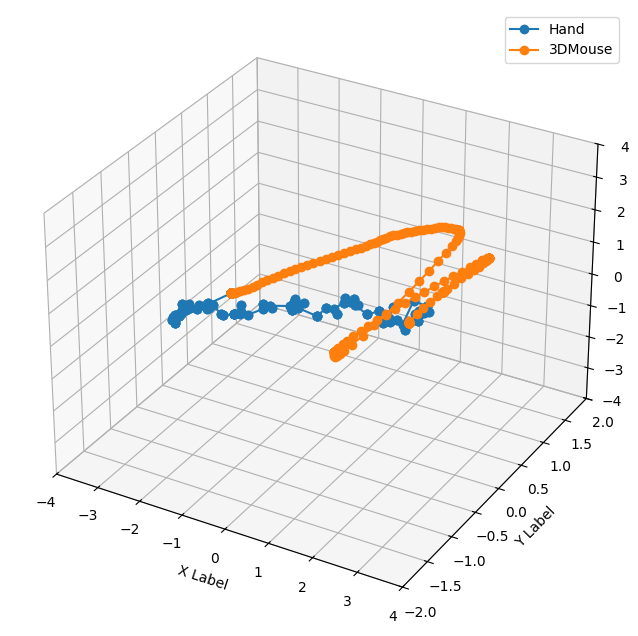

In [608]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(0, 2):
    cond = (allCircuits['CircuitID'] == measureCircuit[3]) & (allCircuits['Conditions'] == conditions[i]) & (allCircuits['User'] == nameList[0]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3)  & (allCircuits['User'] != 'User2')  & (allCircuits['User'] != 'User12') & (allCircuits['User'] != 'User18') 

    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = conditions[i])
    ax.legend()

# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-2, 2), ylabel='Y')
ax.set(zlim3d=(-4, 4), zlabel='Z')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

Text(0.5, 0, 'Z Label')

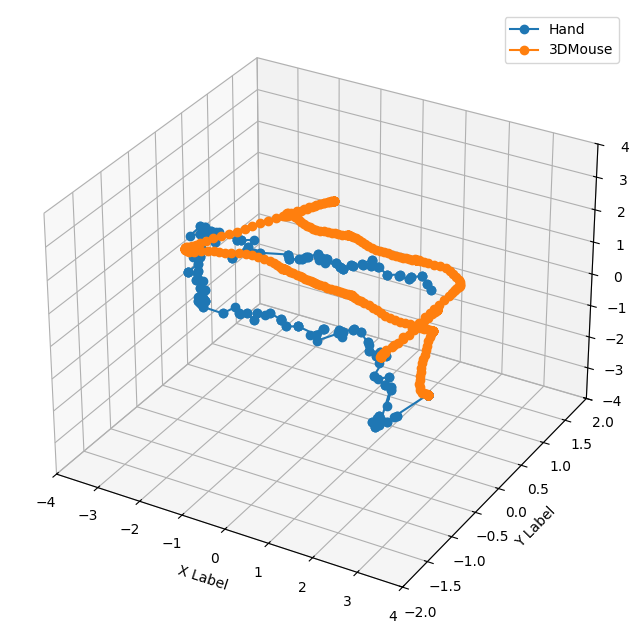

In [609]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(0, 2):
    cond = (allCircuits['CircuitID'] == measureCircuit[4]) & (allCircuits['Conditions'] == conditions[i]) & (allCircuits['User'] == nameList[0]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3)  & (allCircuits['User'] != 'User2')  & (allCircuits['User'] != 'User12') & (allCircuits['User'] != 'User18') 

    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = conditions[i])
    ax.legend()

# Setting the Axes properties
ax.set(xlim3d=(-4, 4), xlabel='X')
ax.set(ylim3d=(-2, 2), ylabel='Y')
ax.set(zlim3d=(-4, 4), zlabel='Z')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

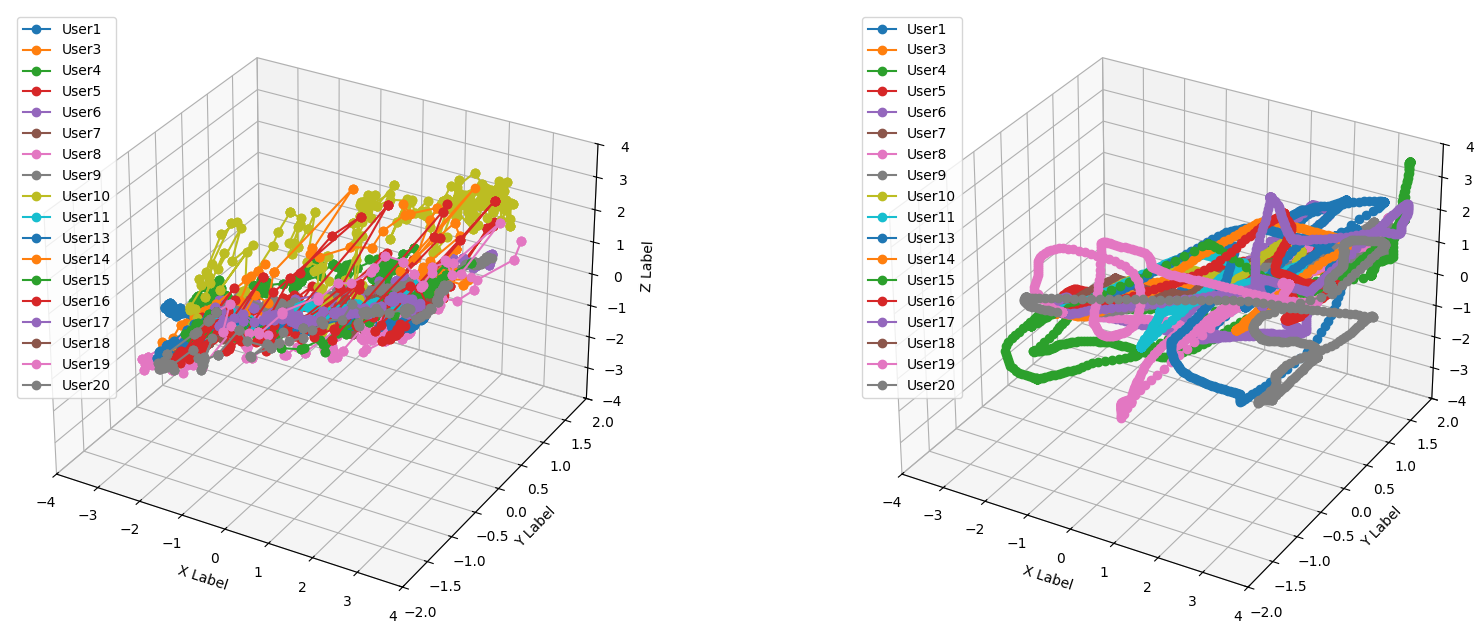

In [610]:
fig = plt.figure(figsize=(20, 8))
k = (k + 1) % len(measureCircuit)
for j in range(0, len(conditions)):
    ax = fig.add_subplot(1, len(conditions), j+1, projection='3d')

    for i in range(0, len(nameList)):
        cond = (allCircuits['CircuitID'] == measureCircuit[k]) & (allCircuits['Conditions'] == conditions[j]) & (allCircuits['User'] == nameList[i])  & (allCircuits['User'] != 'User18') 
    
        ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = nameList[i])
        ax.legend()
    
    # Setting the Axes properties
    ax.set(xlim3d=(-4, 4), xlabel='X')
    ax.set(ylim3d=(-2, 2), ylabel='Y')
    ax.set(zlim3d=(-4, 4), zlabel='Z')
    
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')


Text(0.5, 0, 'Z Label')

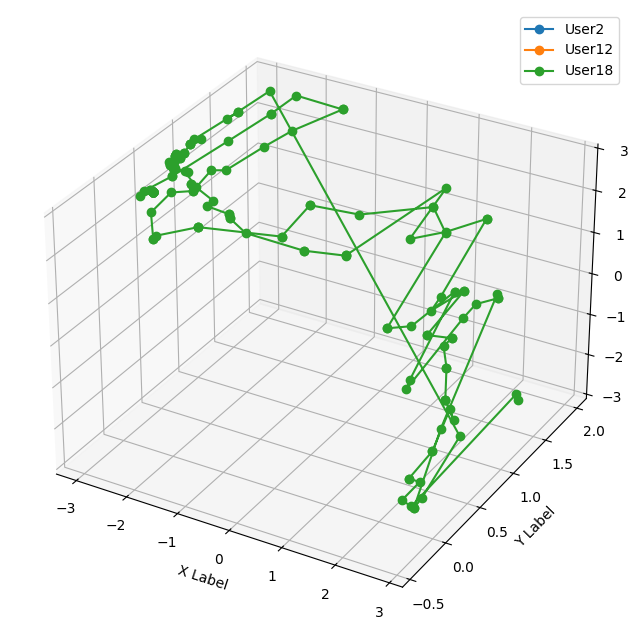

In [611]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

listWeird = ['User2', 'User12', 'User18']
for i in range(0, len(listWeird)):
    cond = (allCircuits['CircuitID'] == 'Circuit0') & (allCircuits['Conditions'] == 'Hand') & (allCircuits['User'] == listWeird[i]) & (allCircuits['PosY'] < 3) & (allCircuits['PosZ'] > -3)  & (allCircuits['PosZ'] < 3) 

    ax.plot(allCircuits[cond]['PosX'], allCircuits[cond]['PosY'], allCircuits[cond]['PosZ'], marker = 'o', label = listWeird[i])
    ax.legend()

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

In [7]:
nasatlx = pd.DataFrame()
nasatlx = pd.read_csv('./UserData/NasaTLX.csv', sep = ';', decimal = '.')
nasatlx['Total'] = (nasatlx['Performance'] + nasatlx['Effort'] + nasatlx['Temporal Demand'] + nasatlx['Physical Demand'] + nasatlx['Mental Demand'])/1.2

del nasatlx['Unnamed: 8']

In [8]:
nasatlx.columns
headerNasa = ['Mental Demand', 'Physical Demand',
       'Temporal Demand', 'Effort', 'Performance', 'Frustration', 'Total']


In [9]:
nasaSummary = pd.DataFrame()

for i in range(0, len(headerNasa)):
    for j in range(0, len(conditions)):
        nasaSummary.loc[headerNasa[i], conditions[j]] = nasatlx[nasatlx['Condition'] == conditions[j]][headerNasa[i]].mean()

nasaSummary

,Hand,3DMouse
Mental Demand,5.80,9.150000
Physical Demand,4.50,3.850000
Temporal Demand,4.75,7.550000
Effort,6.70,9.200000
Performance,5.55,7.800000
Frustration,3.75,5.850000
Total,22.75,31.291667


In [10]:
nasaError = pd.DataFrame()

for i in range(0, len(headerNasa)):
    for j in range(0, len(conditions)):
        nasaError.loc[headerNasa[i], conditions[j]] = nasatlx[nasatlx['Condition'] == conditions[j]][headerNasa[i]].std()/math.sqrt(18)

nasaError

,Hand,3DMouse
Mental Demand,0.984084,1.079514
Physical Demand,0.893446,0.773369
Temporal Demand,0.844227,1.096179
Effort,1.263755,1.229748
Performance,1.347458,1.292353
Frustration,1.056517,0.986087
Total,2.857127,3.191090


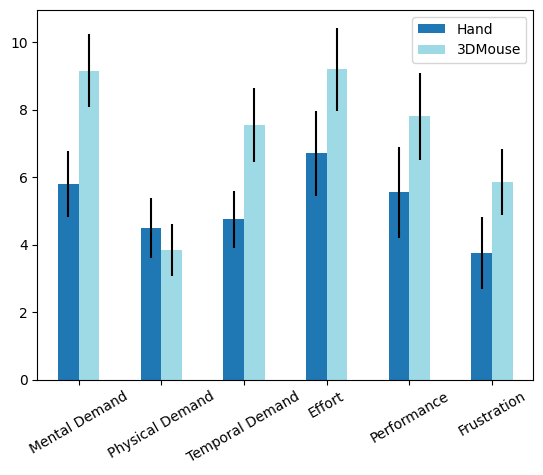

In [11]:
nasaSummary[:-1].plot(kind = 'bar', colormap = 'tab20', rot = 30, yerr = nasaError[:-1], linewidth = 1)
plt.savefig('./NasaTLX.pdf')
plt.show()

In [22]:
nasatlx[nasatlx['Condition'] == 'Hand'].describe()

,Mental Demand,Physical Demand,Temporal Demand,Effort,Performance,Frustration,Total
count,20.000000,20.00000,20.000000,20.000000,20.00000,20.000000,20.000000
mean,5.800000,4.50000,4.750000,6.700000,5.55000,3.750000,22.750000
std,4.175114,3.79057,3.581752,5.361657,5.71678,4.482422,12.121763
min,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,7.500000
25%,3.000000,2.00000,2.000000,2.000000,1.75000,1.000000,12.916667
50%,4.500000,3.00000,3.000000,5.000000,4.00000,2.000000,22.500000
75%,7.000000,6.25000,8.250000,9.250000,6.00000,4.000000,29.375000
max,17.000000,14.00000,11.000000,18.000000,19.00000,17.000000,54.166667


/var/folders/xd/qgqqknts7d16j8g06t07y4yw0000gn/T/ipykernel_41627/3105370807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data = nasatlx, x = 'Condition', y = 'Total', showmeans = True, palette = 'tab20')


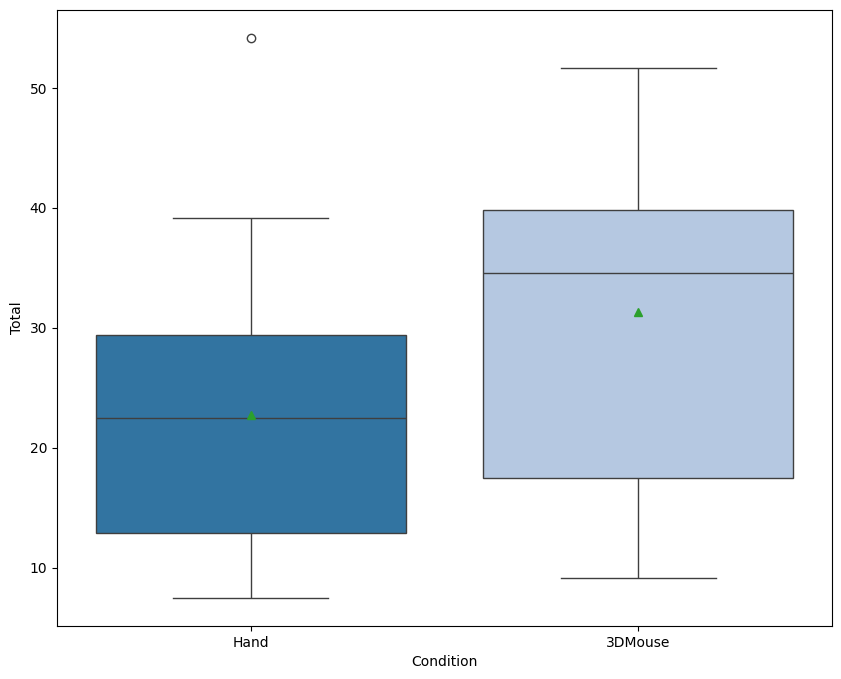

In [21]:
f,ax = plt.subplots(1,1, figsize=(10, 8))

ax = sns.boxplot(data = nasatlx, x = 'Condition', y = 'Total', showmeans = True, palette = 'tab20')

f.savefig('./NasaTLX-total.pdf')


In [14]:
for i in range(0, len(headerNasa)):
    print(headerNasa[i])
    print(pg.rm_anova(data = nasatlx, dv = headerNasa[i], within = ['Condition'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2'))


Mental Demand
      Source       SS  DF          MS         F     p-unc        n2  eps
0  Condition  112.225   1  112.225000  7.690109  0.012112  0.133288  1.0
1      Error  277.275  19   14.593421       NaN       NaN       NaN  NaN
Physical Demand
      Source       SS  DF        MS         F     p-unc       n2  eps
0  Condition    4.225   1  4.225000  0.442835  0.513755  0.00877  1.0
1      Error  181.275  19  9.540789       NaN       NaN      NaN  NaN
Temporal Demand
      Source     SS  DF         MS         F     p-unc        n2  eps
0  Condition   78.4   1  78.400000  9.105134  0.007082  0.106943  1.0
1      Error  163.6  19   8.610526       NaN       NaN       NaN  NaN
Effort
      Source     SS  DF         MS         F    p-unc        n2  eps
0  Condition   62.5   1  62.500000  3.312413  0.08455  0.055511  1.0
1      Error  358.5  19  18.868421       NaN      NaN       NaN  NaN
Performance
      Source       SS  DF         MS         F    p-unc        n2  eps
0  Condition   50.

In [15]:
for i in range(0, len(headerNasa)):
    print(headerNasa[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(nasatlx[headerNasa[i]], groups = nasatlx['Condition'], alpha=0.05))


Mental Demand
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand    -3.35 0.0205 -6.1554 -0.5446   True
-----------------------------------------------------
Physical Demand
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand     0.65 0.5655 -1.6194 2.9194  False
----------------------------------------------------
Temporal Demand
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand     -2.8 0.0394 -5.4572 -0.1428   True
-----------------------------------------------------
Effort
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
------------------------------------

Mental Demand
Physical Demand
Temporal Demand
Effort
Performance
Frustration
Total


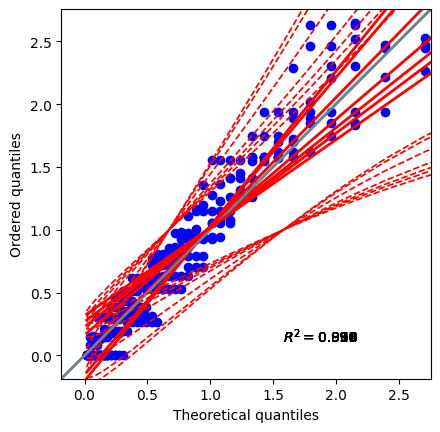

In [621]:
for i in range(0, len(headerNasa)):
    print(headerNasa[i])
    ax = pg.qqplot(nasatlx[headerNasa[i]], dist='expon')

In [585]:
post_hocs = pg.pairwise_tests(dv='StopWatch', within='Conditions', subject='User', data=allCountdowns[(allCountdowns['UX'] == 'PathTracing')])
print(post_hocs)

     Contrast        A     B  Paired  Parametric         T   dof alternative  \
0  Conditions  3DMouse  Hand    True        True  1.503321  16.0   two-sided   

      p-unc   BF10    hedges  
0  0.152237  0.642  0.405204  


In [586]:
allCountdowns[(allCountdowns['UX'] == 'PathTracing') & (allCountdowns['Conditions'] == 'Hand')]['StopWatch'].describe()

count    70.000000
mean      6.604769
std       2.936466
min       1.164454
25%       4.830932
50%       6.345569
75%       8.080054
max      13.949080
Name: StopWatch, dtype: float64

In [587]:
allCountdowns[(allCountdowns['UX'] == 'PathTracing') & (allCountdowns['Conditions'] == '3DMouse')]['StopWatch'].describe()

count    86.000000
mean      7.087260
std       2.607956
min       3.045017
25%       4.873104
50%       6.868714
75%       8.701785
max      13.320020
Name: StopWatch, dtype: float64

In [280]:
allCircuits.reset_index().to_csv('./CleanedCircuits.csv')



In [290]:
for i in range(0, len(measureCircuit)):
    for k in range(0, len(conditions)):
        cond = (allCircuits['CircuitID'] == measureCircuit[i]) & (allCircuits['Conditions'] == conditions[k])
        allCircuits[cond].reset_index().to_csv('./CleanedCircuits_'+str(i)+'-' + conditions[k] +'.csv', sep = ';', decimal = ',')

In [288]:
allCircuits[cond]

,BlockID,Frame,StopWatch,PosX,PosY,PosZ,User,Conditions,CircuitID,UX,PositionAbsolute,PositionSubstraction
0,0,1,0.049927,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.000000
1,0,3,0.084286,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.000000
2,0,4,0.101349,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.000000
3,0,5,0.120125,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.000000
4,0,6,0.139626,1.7021,0.6160,-2.8520,User20,3DMouse,Circuit4,PathTracing,3.377944,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
383,0,385,7.267586,3.1609,-0.6046,2.0157,User1,3DMouse,Circuit4,PathTracing,3.797351,0.129395
384,0,386,7.284378,3.1609,-0.6046,2.0157,User1,3DMouse,Circuit4,PathTracing,3.797351,0.135553
385,0,387,7.301792,3.1609,-0.6046,2.0157,User1,3DMouse,Circuit4,PathTracing,3.797351,0.140746
386,0,388,7.318657,3.1609,-0.6046,2.0157,User1,3DMouse,Circuit4,PathTracing,3.797351,0.145869


In [297]:
spreadDataFrame[spreadDataFrame['Distance'] == 1.7647]

,Frame,Time,User,Condition,Config,Distance,Conditions
0,1,"0,01512527",User20,3DMouse,0,1.7647,3DMouse
1,2,"0,06541443",User20,3DMouse,0,1.7647,3DMouse
2,3,"0,09008026",User20,3DMouse,0,1.7647,3DMouse
3,4,"0,1138687",User20,3DMouse,0,1.7647,3DMouse
4,5,"0,1370735",User20,3DMouse,0,1.7647,3DMouse
...,...,...,...,...,...,...,...
5487,5488,"5,831165",User1,Hand,0,1.7647,Hand
5488,5489,"5,853474",User1,Hand,0,1.7647,Hand
5489,5490,"5,879215",User1,Hand,0,1.7647,Hand
5490,5491,"5,906803",User1,Hand,0,1.7647,Hand


In [21]:
spreadDataFrame = pd.DataFrame()
for k in range(0, len(conditions)):
    spreadData = None   
    spreadData = pd.read_csv('./AllCircuits_Distances-' + conditions[k] + '.csv', sep = ';', decimal = '.')
    spreadData['Conditions'] = conditions[k]
    spreadDataFrame = pd.concat([spreadData, spreadDataFrame], axis = 0)

spreadDataFrame.head()

,Frame,Time,User,Condition,Config,Distance,Conditions
0,1,"0,01512527",User20,3DMouse,0,2.4023,3DMouse
1,2,"0,06541443",User20,3DMouse,0,2.4023,3DMouse
2,3,"0,09008026",User20,3DMouse,0,2.4023,3DMouse
3,4,"0,1138687",User20,3DMouse,0,2.4023,3DMouse
4,5,"0,1370735",User20,3DMouse,0,2.4023,3DMouse


In [22]:
spreadDataFrame.head()
#spreadDataFrame = spreadDataFrame.drop((spreadDataFrame[spreadDataFrame['Distance'] == 1.7647].index))
spreadDataFrame = spreadDataFrame.drop((spreadDataFrame[spreadDataFrame['Distance'] == 2.4023].index))


#spreadDataFrame = spreadDataFrame.drop((spreadDataFrame[spreadDataFrame['Distance'] == 0].index))


In [23]:
for k in range(0, len(conditions)):
    for j in range(0, len(measureCircuit)):
        for i in range(0, len(nameList)):
            cond = (spreadDataFrame['Conditions'] == conditions[k]) & (spreadDataFrame['User'] == nameList[i]) & (spreadDataFrame['Config'] == j)
            spreadDataFrame.loc[cond,'Sum'] = spreadDataFrame[cond]['Distance'].mean()
            

In [24]:
circuitDistancePerUser = pd.DataFrame()
circuitDistancePerCircuit = pd.DataFrame()

for k in range(0, len(conditions)):
    cond = (spreadDataFrame['Conditions'] == conditions[k])

    for j in range(0, len(measureCircuit)):
        toaverage = 0
        todivide = 0
        for i in range(0, len(nameList)):
            circuitDistancePerUser.loc[nameList[i], measureCircuit[j]+'-'+conditions[k]] = 2*spreadDataFrame[cond & (spreadDataFrame['User'] == nameList[i]) & (spreadDataFrame['Config'] == j)]['Distance'].mean()
            toaverage = toaverage + 2*spreadDataFrame[cond & (spreadDataFrame['User'] == nameList[i]) & (spreadDataFrame['Config'] == j)]['Distance'].mean()
            todivide = todivide + 1
        circuitDistancePerCircuit.loc[measureCircuit[j], conditions[k]] = toaverage/todivide



In [25]:
fuckindata = pd.DataFrame()
addLine = 0

for k in range(0, len(conditions)):
    for j in range(0, len(measureCircuit)):
        for i in range(0, len(nameList)):
            fuckindata.loc[addLine, 'CircuitID'] = measureCircuit[j]
            fuckindata.loc[addLine, 'User'] = nameList[i]
            fuckindata.loc[addLine, 'Conditions'] = conditions[k]
            fuckindata.loc[addLine, 'Average'] = circuitDistancePerUser.loc[nameList[i], measureCircuit[j]+'-'+conditions[k]]
            
            addLine = addLine + 1


In [26]:
fuckindata

,CircuitID,User,Conditions,Average
0,Circuit0,User1,Hand,1.365050
1,Circuit0,User3,Hand,1.635617
2,Circuit0,User4,Hand,0.774169
3,Circuit0,User5,Hand,1.535941
4,Circuit0,User6,Hand,1.886258
...,...,...,...,...
175,Circuit4,User16,3DMouse,1.032033
176,Circuit4,User17,3DMouse,1.323193
177,Circuit4,User18,3DMouse,1.476393
178,Circuit4,User19,3DMouse,1.230278


In [27]:
fuckindata[(fuckindata['Conditions'] == 'Hand')].describe()



,Average
count,90.000000
mean,1.055501
std,0.650177
min,0.014687
25%,0.439568
50%,1.120555
75%,1.531986
max,2.455169


In [28]:
fuckindata[(fuckindata['Conditions'] == '3DMouse')].describe()


,Average
count,90.000000
mean,1.096202
std,0.661620
min,0.077551
25%,0.551076
50%,1.034488
75%,1.538325
max,3.385538


In [29]:
circuitDistancePerCircuit

,Hand,3DMouse
Circuit0,1.448439,1.584551
Circuit1,0.684920,0.710908
Circuit2,1.655885,1.671816
Circuit3,0.140679,0.312811
Circuit4,1.347579,1.200924


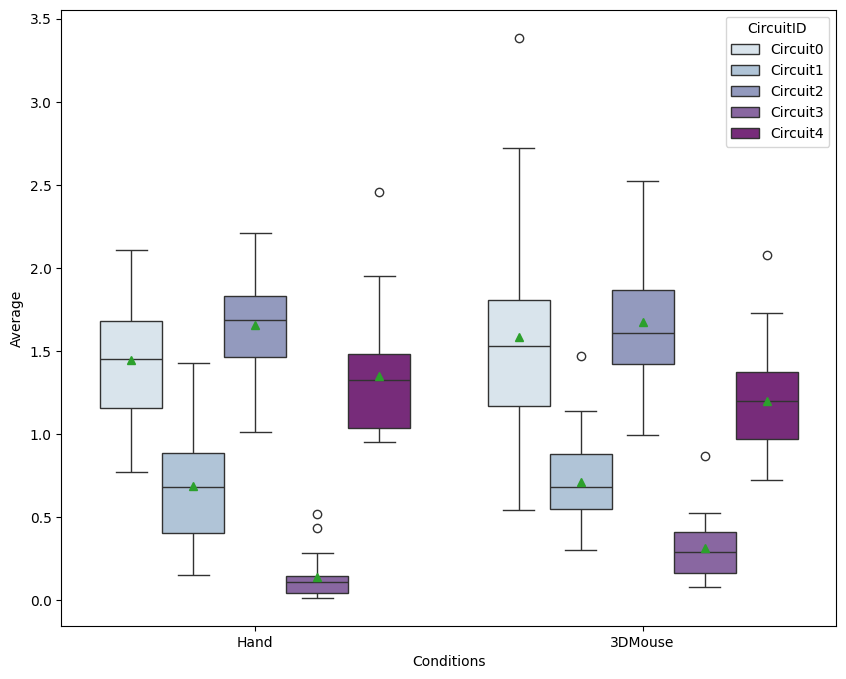

In [30]:
f,ax = plt.subplots(1,1, figsize=(10, 8))

ax = sns.boxplot(data = fuckindata, x = 'Conditions', y = 'Average', hue = 'CircuitID', showmeans = True, palette = 'BuPu', notch = False)

f.savefig('./circuitPercond.pdf')

In [31]:
circuitDistancePerUser

,Circuit0-Hand,Circuit1-Hand,Circuit2-Hand,Circuit3-Hand,Circuit4-Hand,Circuit0-3DMouse,Circuit1-3DMouse,Circuit2-3DMouse,Circuit3-3DMouse,Circuit4-3DMouse
User1,1.365050,0.735869,1.473524,0.113181,1.065056,1.340553,0.688528,1.597750,0.267713,1.228068
User3,1.635617,0.628215,1.457948,0.145558,1.026822,1.651609,0.360495,1.757978,0.138672,0.844736
User4,0.774169,0.761008,1.285861,0.117488,1.010268,1.982085,0.886835,1.256128,0.329734,0.828541
User5,1.535941,0.351766,1.762278,0.098676,0.952223,1.519856,0.555164,1.685369,0.189671,1.389866
User6,1.886258,0.306451,1.265015,0.120302,1.953021,1.815076,0.576834,1.791622,0.354455,0.771016
User7,1.822811,1.023084,1.974063,0.149392,1.350775,0.542077,0.320097,1.281562,0.267365,0.720492
User8,2.106810,1.237116,1.763528,0.435876,1.391266,0.610895,0.852700,2.218197,0.455682,1.731226
User9,2.103815,0.154215,1.010214,0.014687,0.959764,1.289249,0.564478,1.555205,0.180548,1.036943
User10,1.218457,1.426803,2.208354,0.282263,2.455169,2.722277,0.300489,1.584390,0.077551,1.171573
User11,1.251357,0.450643,1.474637,0.019795,0.977120,1.127366,0.549713,1.330755,0.160040,1.250441


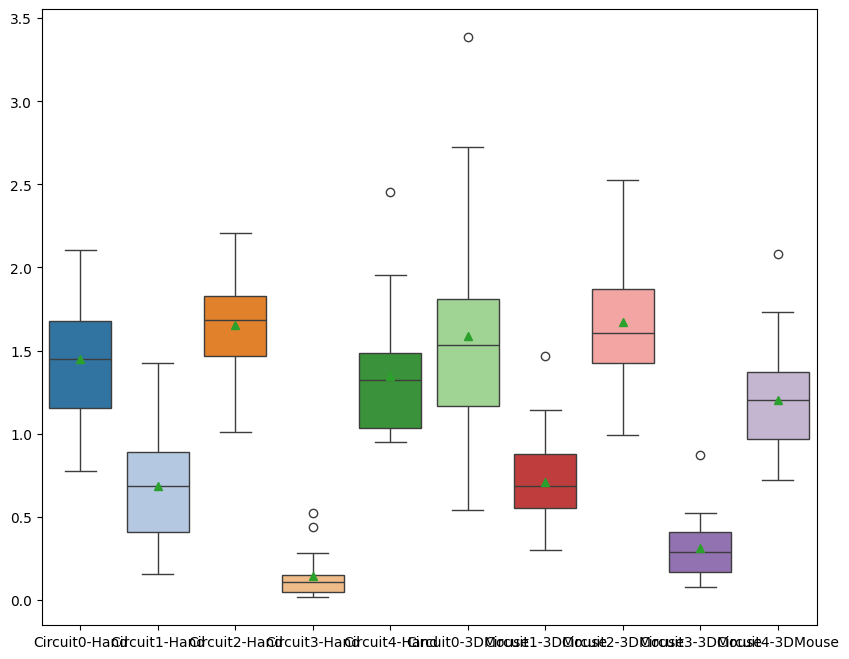

In [32]:
f,ax = plt.subplots(1,1, figsize=(10, 8))

ax = sns.boxplot(data = circuitDistancePerUser, showmeans = True, palette = 'tab20', notch = False)

f.savefig('./circuitPerCircuit.pdf')

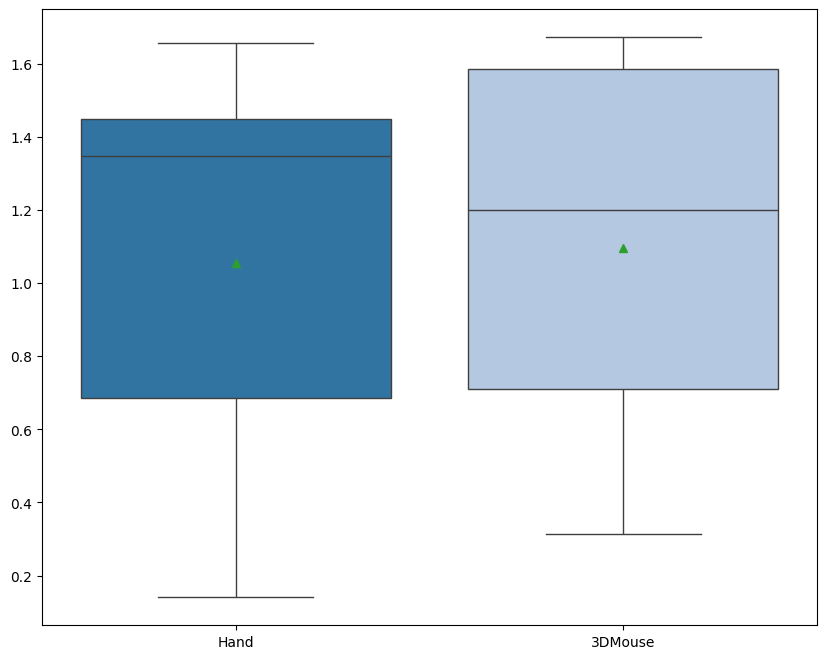

In [33]:
f,ax = plt.subplots(1,1, figsize=(10, 8))

ax = sns.boxplot(data = circuitDistancePerCircuit, showmeans = True, palette = 'tab20', notch = False)

f.savefig('./circuitPerCond.pdf')

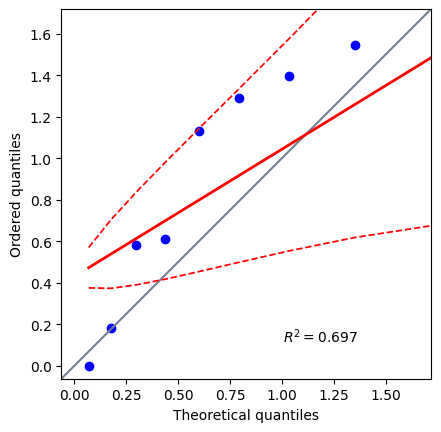

In [34]:
ax = pg.qqplot(circuitDistancePerCircuit, dist='expon')

In [35]:
pg.sphericity(data = spreadDataFrame, 
            dv = 'Distance', within = ['Conditions'], subject = 'User')

(True, nan, nan, 1, 1.0)

In [36]:
pg.rm_anova(data = spreadDataFrame, 
            dv = 'Distance', within = ['Conditions', 'Config'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')



/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,0.018637,1,17,0.018637,0.371761,5.501094e-01,5.501094e-01,0.000972,1.000000
1,Config,12.987811,4,68,3.246953,127.088538,8.571645e-31,2.358532e-21,0.677715,0.669338
2,Conditions * Config,0.140196,4,68,0.035049,1.008165,4.094638e-01,3.748791e-01,0.007316,0.494352


In [37]:
pg.rm_anova(data = fuckindata, 
            dv = 'Average', within = ['Conditions', 'CircuitID'], subject = 'User', correction = 'auto', detailed = True, effsize = 'n2')



/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/elodie.bouzbib/Library/Python/3.9/lib/python/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps
0,Conditions,0.074548,1,17,0.074548,0.371761,5.501094e-01,5.501094e-01,0.000972,1.000000
1,CircuitID,51.951246,4,68,12.987811,127.088538,8.571645e-31,2.358532e-21,0.677715,0.669338
2,Conditions * CircuitID,0.560784,4,68,0.140196,1.008165,4.094638e-01,3.748791e-01,0.007316,0.494352


In [38]:
for i in range(0, len(measureCircuit)):
    print(measureCircuit[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(fuckindata[fuckindata['CircuitID'] == measureCircuit[i]]['Average'], groups = fuckindata[fuckindata['CircuitID'] == measureCircuit[i]]['Conditions'], alpha=0.05))



Circuit0
Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1 group2 meandiff p-adj   lower  upper reject
---------------------------------------------------
3DMouse   Hand  -0.1361 0.4729 -0.5172 0.245  False
---------------------------------------------------
Circuit1
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand   -0.026 0.8128 -0.2473 0.1953  False
----------------------------------------------------
Circuit2
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand  -0.0159 0.8911 -0.2507 0.2189  False
----------------------------------------------------
Circuit3
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Ha

In [39]:
print(sm.stats.multicomp.pairwise_tukeyhsd(spreadDataFrame['Distance'], groups = spreadDataFrame['Conditions'], alpha=0.05))



 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand  -0.0154 0.0001 -0.0232 -0.0076   True
-----------------------------------------------------


In [40]:
for i in range(0, len(measureCircuit)):
    print(measureCircuit[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(spreadDataFrame[spreadDataFrame['Config'] == i]['Distance'], groups = spreadDataFrame[spreadDataFrame['Config'] == i]['Conditions'], alpha=0.05))



Circuit0
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand  -0.0457 0.0004 -0.0709 -0.0206   True
-----------------------------------------------------
Circuit1
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand  -0.0112 0.0888 -0.0241 0.0017  False
----------------------------------------------------
Circuit2
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand  -0.0185 0.0294 -0.0352 -0.0019   True
-----------------------------------------------------
Circuit3
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------


In [41]:
for i in range(0, len(measureCircuit)):
    print(measureCircuit[i])
    print(sm.stats.multicomp.pairwise_tukeyhsd(spreadDataFrame[spreadDataFrame['Config'] == i]['Distance'], groups = spreadDataFrame[spreadDataFrame['Config'] == i]['Conditions'], alpha=0.05))


Circuit0
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand  -0.0457 0.0004 -0.0709 -0.0206   True
-----------------------------------------------------
Circuit1
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
3DMouse   Hand  -0.0112 0.0888 -0.0241 0.0017  False
----------------------------------------------------
Circuit2
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
3DMouse   Hand  -0.0185 0.0294 -0.0352 -0.0019   True
-----------------------------------------------------
Circuit3
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
